# TaxoGraph-BERT — Pipeline Lengkap

Notebook ini mengimplementasikan seluruh alur dari paper TaxoGraph-BERT:

| Seksi | Topik |
|---|---|
| 0 | Setup & Konfigurasi Global |
| 1 | Konfigurasi Hyperparameter |
| 2 | Preprocessing SILVA (HDF5 pipeline) |
| 3 | Eksplorasi Data |
| 4 | Dataset & DataLoader |
| 5 | Hyperbolic GNN |
| 6 | Build Model TaxoGraph-BERT |
| 7 | Training (Phase 1 + Phase 2) |
| 8 | Evaluasi Post-Training |
| 9 | Mockrobiota Benchmark (Sec. 4.1) |
| 10 | OOD Detection — NCBI Hold-out (Sec. 4.2) |
| 11 | Ablation Study (Sec. 4.3) |
| 12 | Inferensi & Export |

In [ ]:
import os

folder = "/kaggle/working/outputs/checkpoints/"

files = os.listdir(folder)

for f in files:
    print(f)

In [ ]:
import os
from datetime import datetime

path = "/kaggle/working/outputs/checkpoints/taxograph_bert_v1_best.pt"

if os.path.isfile(path):
    # ukuran file
    size_mb = os.path.getsize(path) / (1024 * 1024)

    # waktu terakhir dimodifikasi
    modified_time = os.path.getmtime(path)
    modified_datetime = datetime.fromtimestamp(modified_time)

    print(f"File ada ✅")
    print(f"Ukuran : {size_mb:.2f} MB")
    print(f"Last Update : {modified_datetime.strftime('%Y-%m-%d %H:%M:%S')}")

else:
    print("File tidak ditemukan ❌")

In [ ]:
import shutil
from pathlib import Path
from IPython.display import FileLink

# =========================
# DAFTAR FILE YANG INGIN DIDOWNLOAD
# =========================
files_to_zip = [
    "/kaggle/working/outputs/checkpoints/taxograph_bert_v1_latest.pt",
    "/kaggle/working/outputs/checkpoints/phase1_hgnn.pt",
    "/kaggle/working/outputs/metrics/taxograph_bert_v1_train_log.csv",
]

# =========================
# FOLDER SEMENTARA
# =========================
temp_dir = Path("/kaggle/working/temp_download")
temp_dir.mkdir(exist_ok=True)

# =========================
# COPY FILE KE FOLDER SEMENTARA
# =========================
for file_path in files_to_zip:
    file_path = Path(file_path)

    if file_path.exists():
        shutil.copy(file_path, temp_dir / file_path.name)
        print(f"✅ Ditambahkan: {file_path.name}")
    else:
        print(f"❌ Tidak ditemukan: {file_path}")

# =========================
# BUAT ZIP
# =========================
zip_path = "/kaggle/working/model_backup"

shutil.make_archive(
    zip_path,
    'zip',
    temp_dir
)

print("\nZIP selesai dibuat ✅")

# =========================
# LINK DOWNLOAD
# =========================
FileLink(zip_path + ".zip")

In [ ]:
from pathlib import Path
import shutil


def delete(
    path=None,
    extension=None,
    delete_folder=False,
    recursive=True,
):
    """
    Fungsi universal untuk menghapus:
    1. Satu file
    2. Semua file dengan ekstensi tertentu
    3. Semua isi folder
    4. Folder beserta isinya

    Parameters
    ----------
    path : str
        Path file/folder target

    extension : str, optional
        Ekstensi file yang ingin dihapus
        contoh: ".pt", ".csv"

    delete_folder : bool, default=False
        Jika True:
            folder target ikut dihapus

        Jika False:
            hanya isi folder yang dihapus

    recursive : bool, default=True
        Cari file secara rekursif ke subfolder
    """

    if path is None:
        print("Path harus diberikan")
        return

    target = Path(path)

    if not target.exists():
        print(f"Path tidak ditemukan: {target}")
        return

    # =========================================================
    # MODE 1 — Hapus berdasarkan ekstensi
    # =========================================================
    if extension is not None:

        pattern = f"*{extension}"

        files = (
            target.rglob(pattern)
            if recursive
            else target.glob(pattern)
        )

        files = list(files)

        if not files:
            print(f"Tidak ada file {extension}")
            return

        for file in files:
            if file.is_file():
                file.unlink()

        print(f"{len(files)} file {extension} berhasil dihapus")
        return

    # =========================================================
    # MODE 2 — Hapus satu file
    # =========================================================
    if target.is_file():
        target.unlink()
        print(f"File dihapus: {target}")
        return

    # =========================================================
    # MODE 3 — Hapus isi folder
    # =========================================================
    if target.is_dir():

        for item in target.iterdir():

            if item.is_file():
                item.unlink()

            elif item.is_dir():
                shutil.rmtree(item)

        # =====================================================
        # MODE 4 — Hapus folder juga
        # =====================================================
        if delete_folder:
            target.rmdir()
            print(f"Folder dan seluruh isinya dihapus: {target}")
        else:
            print(f"Isi folder dibersihkan: {target}")


# # Hapus satu file
# delete("outputs/model.pt")

# # Hapus semua .pt
# delete("outputs", extension=".pt")

# # Hapus semua .csv rekursif
# delete("logs", extension=".csv", recursive=True)

# # Bersihkan isi folder
# delete("outputs")

# # Hapus folder beserta seluruh isinya
# delete("outputs", delete_folder=True)

---
## 0. Setup & Dependensi

Instalasi paket dan konfigurasi gaya plot global (journal Q1: DPI=300, font serif, spines bersih).
Jalankan sel ini sekali, restart kernel jika diminta.


In [ ]:
#@title **Install Conda di Colab**
#@markdown It will restart the kernel (session), don't worry.
!pip install -q condacolab
import condacolab
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")

# !conda install bioconda::vsearch -y

In [ ]:
import subprocess
import sys
import importlib.metadata
import re  # Tambahkan regex
from typing import List, Optional

def safe_install(*packages: str, provider: str = "pip"):
    to_install = []

    print(f"\n🔍 [Sistem Audit Library - Provider: {provider.upper()}]")
    print("-" * 50)

    for package_str in packages:
        # 1. Parsing Cerdas: Memisahkan nama dari operator (==, >=, <=, >, <)
        # Regex ini memisahkan teks sebelum simbol perbandingan pertama
        match = re.split(r'(==|>=|<=|>|<)', package_str)
        pkg_name = match[0].strip().lower()

        # Jika ada operator, ambil versi dan operatornya
        full_spec = "".join(match[1:]) if len(match) > 1 else None
        requested_version = match[2].strip() if len(match) > 2 else None

        # 2. Cek status instalasi asli (hanya pakai nama bersih)
        installed_version = None
        try:
            installed_version = importlib.metadata.version(pkg_name)
            is_installed = True
        except importlib.metadata.PackageNotFoundError:
            is_installed = False

        # 3. Logika Evaluasi Baru
        if is_installed:
            # Jika user minta versi spesifik (baik itu == atau >=)
            if full_spec:
                # Cek apakah versi terinstall sudah memenuhi kriteria secara sederhana
                # Untuk akurasi 100% kita bisa pakai library 'packaging',
                # tapi di sini kita pakai logika konfirmasi jika ada perbedaan versi.
                if installed_version == requested_version:
                     print(f"✅ {pkg_name:<15} | Versi: {installed_version} (Sesuai)")
                     continue
                else:
                    print(f"⚠️ {pkg_name:<15} | Konflik! Terinstall: {installed_version}, Diminta: {package_str}")
                    confirm = input(f"    --> Proses dengan {provider}? (y/n): ")
                    if confirm.lower() == 'y':
                        to_install.append(package_str)
            else:
                print(f"✅ {pkg_name:<15} | Terinstall: {installed_version} (Sesuai)")
        else:
            print(f"❌ {pkg_name:<15} | Belum ada di sistem.")
            to_install.append(package_str)

    # 4. Eksekusi Batch
    if not to_install:
        print("-" * 50)
        print("🎉 Semua library sudah siap.")
        return

    print("-" * 50)
    print(f"🚀 Menginstal: {', '.join(to_install)}...")

    try:
        if provider == "pip":
            subprocess.check_call([sys.executable, "-m", "pip", "install", *to_install])
        print(f"✨ Selesai!")
    except Exception as e:
        print(f"🔥 Error: {e}")

# 1. Memanggil banyak library sekaligus (seperti permintaan Anda)
safe_install("torch",
             "torchvision",
             "torchaudio",
             "peft",
             "transformers",
             "accelerate",
             "huggingface_hub",
             "safetensors",
             "h5py",
             "loguru",
             "biopython",
             "geoopt",
             "einops",
             "triton",
             "scikit-learn",
             "scipy",
             "tqdm",
             "matplotlib",
             "torchao>=0.16.0"
            )

import os
os._exit(0)

In [ ]:
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt

import torch
import torchvision

print(f"NumPy        : {np.__version__}")
print(f"Torch        : {torch.__version__}")
print(f"TorchVision  : {torchvision.__version__}")
print(f"CUDA         : {torch.version.cuda}")
print(f"CUDA         : {torch.cuda.is_available()}")
print(f"GPU          : {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "Tidak ada GPU CUDA")
# print(f"MPS     : {torch.backends.mps.is_available()}")

In [ ]:
#@title ── Konfigurasi gaya plot global (journal Q1) ─────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl

JOURNAL_RC = {
    # Font
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.labelsize":     11,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    # Lines & markers
    "lines.linewidth":    1.5,
    "lines.markersize":   5,
    # Axes
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "grid.alpha":         0.3,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
    # Figure
    "figure.dpi":         150,       # pantai (150); simpan ke 300 via savefig
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.format":     "png",
    # Color
    "axes.prop_cycle": mpl.cycler(color=[
        "#1f77b4", "#d62728", "#2ca02c", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22",
        "#17becf", "#ff7f0e",
    ]),
}
mpl.rcParams.update(JOURNAL_RC)

# ── Palet warna tetap ────────────────────────────────────────────────────────
PALETTE = [
    "#1f77b4", "#d62728", "#2ca02c", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22",
    "#17becf", "#ff7f0e",
]
print("✓ Gaya plot journal Q1 diaktifkan.")


✓ Gaya plot journal Q1 diaktifkan.


---
## 1. Konfigurasi

Semua hyperparameter, path, dan flag dikontrol melalui `Config`.
Sesuaikan path input sebelum menjalankan pipeline.

| Komponen | Nilai Default |
|---|---|
| Backbone | DNABERT-2-117M |
| k-mer k | 6 (vocab = 4096) |
| Poincaré dim | 128, c = 1.0 |
| LoRA r | 16, α = 32 |
| Batch efektif | 32 × 8 = 256 |
| Epochs Phase 1 | 200 (HyTaxGNN pretrain) |
| Val fraction | 10% |


In [ ]:
#@title Download folder `app` dari GitHub (sparse clone)
import os
import shutil
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/setiawantirta/TaxoGraph-Bert.git"

# ── Deteksi environment (cermin dari sel Konfigurasi) ────────────────────────
_in_kaggle = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))
try:
    import google.colab  # noqa: F401
    _in_colab = True and not _in_kaggle
except ImportError:
    _in_colab = False

# ── Tentukan target direktori app ────────────────────────────────────────────
if _in_colab:
    # Google Drive sudah/akan di-mount di sel Konfigurasi;
    # folder app diasumsikan sudah ada di Drive — lewati download.
    print("ℹ  Colab: pastikan folder app sudah ada di Google Drive.")
    _app_target = None
elif _in_kaggle:
    _app_target = Path("/kaggle/working/app")
else:
    _app_target = Path("app").resolve()

# ── Download jika belum ada ──────────────────────────────────────────────────
if _app_target is not None:
    if _app_target.exists():
        print(f"✓ Folder app sudah ada di: {_app_target}")
    else:
        print(f"↓ Men-download folder 'app' dari {REPO_URL} ...")
        _tmp = Path("/tmp/taxograph_bert_sparse")
        if _tmp.exists():
            shutil.rmtree(_tmp)

        # Sparse clone — unduh metadata saja, belum checkout file
        subprocess.run(
            ["git", "clone", "--filter=blob:none", "--no-checkout", "--depth=1",
             REPO_URL, str(_tmp)],
            check=True
        )
        # Aktifkan sparse-checkout, batasi hanya folder app/
        subprocess.run(
            ["git", "-C", str(_tmp), "sparse-checkout", "init", "--cone"],
            check=True
        )
        subprocess.run(
            ["git", "-C", str(_tmp), "sparse-checkout", "set", "app"],
            check=True
        )
        subprocess.run(["git", "-C", str(_tmp), "checkout"], check=True)

        # Salin app/ ke lokasi target, lalu bersihkan clone sementara
        shutil.copytree(str(_tmp / "app"), str(_app_target))
        shutil.rmtree(_tmp)

        print(f"✓ Folder app berhasil di-download ke: {_app_target}")

In [ ]:
#@title Konfigurasi
import sys
import os
import platform
import importlib.util
import torch
from pathlib import Path

Folder_Name = "taxograph-bert-1" #@param {type:"string"}

# ── Deteksi lingkungan: Kaggle → Colab → Local & Sistem Operasi ───────────────
# Kaggle dideteksi PERTAMA karena Kaggle kadang punya google.colab yang bisa diimport
# (akan menyebabkan false positive jika Colab dicek lebih dulu)
IN_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))

try:
    import google.colab  # noqa: F401
    IN_COLAB = True and not IN_KAGGLE  # paksa False jika sebenarnya di Kaggle
except ImportError:
    IN_COLAB = False

SYSTEM_OS = platform.system().lower()  # 'windows', 'darwin' (macOS), atau 'linux'

# Perhitungan jumlah CPU Windows lokal secara dinamis
if SYSTEM_OS == "windows":
    # Gunakan semua core yang tersedia, sisakan 1 core agar OS Windows tetap responsif
    total_cpus = os.cpu_count() or 1
    WINDOWS_WORKERS = max(1, total_cpus - 1)
else:
    WINDOWS_WORKERS = 0


if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    _DRIVE   = Path(f"/content/drive/MyDrive/RKI/{Folder_Name}")
    APP_DIR  = _DRIVE / "app"
    DATA_DIR = _DRIVE                      # input FASTA/TSV dari Drive
    OUT_DIR  = Path(f"{_DRIVE}/outputs")   # output ke Drive (I/O lebih cepat)
    _PROC    = Path(f"{_DRIVE}/data/processed")
    _EXT     = Path(f"{_DRIVE}/data/external")
    _SRC     = _DRIVE / "src"             # lokasi FASTA/TSV sumber
elif IN_KAGGLE:
    APP_DIR  = Path("/kaggle/working/app")
    DATA_DIR = Path("/kaggle/working")
    OUT_DIR  = Path("/kaggle/working/outputs")
    _PROC    = Path("/kaggle/working/data/processed")
    _EXT     = Path("/kaggle/working/data/external")
    # Dataset di-attach via Kaggle Datasets (read-only di /kaggle/input/)
    _SRC     = Path("/kaggle/input/datasets/indoborutoofficial/v3-v4-hyper-region-filter")
else:
    APP_DIR  = Path("app").resolve()
    DATA_DIR = Path(".").resolve()
    OUT_DIR  = Path("outputs").resolve()
    _PROC    = Path("data/processed")
    _EXT     = Path("data/external")
    _SRC     = DATA_DIR / "src"           # lokasi FASTA/TSV sumber

# Pastikan APP_DIR ada di sys.path (insert di posisi 0 agar tidak tertimpa paket lain)
_app_str = str(APP_DIR)
if _app_str not in sys.path:
    sys.path.insert(0, _app_str)
else:
    # Pindahkan ke posisi 0 jika sudah ada di tempat lain agar prioritas tertinggi
    sys.path.remove(_app_str)
    sys.path.insert(0, _app_str)

for d in [OUT_DIR / "checkpoints", OUT_DIR / "metrics", OUT_DIR / "plots",
          OUT_DIR / "embeddings", _PROC, _EXT / "mockrobiota"]:
    Path(d).mkdir(parents=True, exist_ok=True)

# ── Import Config via path eksplisit (tahan terhadap shadowing & path cache) ──

if IN_KAGGLE:
    # Kaggle: import eksplisit via path untuk menghindari konflik sys.path
    import importlib.util as _ilu

    def _load_app_module(mod_name):
        _spec = _ilu.spec_from_file_location(mod_name, str(APP_DIR / f"{mod_name}.py"))
        _mod  = _ilu.module_from_spec(_spec)
        import sys as _sys
        _sys.modules[mod_name] = _mod
        _spec.loader.exec_module(_mod)
        return _mod

    _config_mod     = _load_app_module("config")
    _preprocess_mod = _load_app_module("Preprocess")
    _dataset_mod    = _load_app_module("dataset")

    Config = _config_mod.Config
    parse_silva_taxonomy     = _preprocess_mod.parse_silva_taxonomy
    is_uninformative         = _preprocess_mod.is_uninformative
    count_ambiguous_bases    = _preprocess_mod.count_ambiguous_bases
    apply_unk_token          = _preprocess_mod.apply_unk_token
    deduplicate_lca          = _preprocess_mod.deduplicate_lca
    remove_chimeras          = _preprocess_mod.remove_chimeras
    rollup_taxa              = _preprocess_mod.rollup_taxa
    HierarchicalLabelEncoder = _preprocess_mod.HierarchicalLabelEncoder
    TAX_RANKS                = _preprocess_mod.TAX_RANKS
    KmerTokenizer            = _dataset_mod.KmerTokenizer

else:
    from config import Config
    from Preprocess import (
        parse_silva_taxonomy,
        is_uninformative,
        count_ambiguous_bases,
        apply_unk_token,
        deduplicate_lca,
        remove_chimeras,
        rollup_taxa,
        HierarchicalLabelEncoder,
        TAX_RANKS,
    )
    from dataset import KmerTokenizer

# ── Instansiasi Config ───────────────────────────────────────────────────────
cfg = Config()

# Paths — semua absolut agar portabel antara Colab, Kaggle, dan local
cfg.paths.silva_fasta        = str(_SRC / "0_dna-sequences-silva-v3-v4.fasta")
cfg.paths.silva_taxonomy     = str(_SRC / "0_taxonomy.tsv")
cfg.paths.hdf5_train         = str(_PROC / "silva_train.h5")
cfg.paths.hdf5_val           = str(_PROC / "silva_val.h5")
cfg.paths.taxonomy_graph     = str(_PROC / "taxonomy_graph.pkl")
cfg.paths.label_encoder      = str(_PROC / "label_encoder.pkl")
cfg.paths.vocab_bpe          = str(_PROC / "bpe_vocab.json")
cfg.paths.output_dir         = str(OUT_DIR)
cfg.paths.checkpoint_dir     = str(OUT_DIR / "checkpoints")
cfg.paths.plot_dir           = str(OUT_DIR / "plots")
cfg.paths.metric_dir         = str(OUT_DIR / "metrics")
cfg.paths.embedding_dir      = str(OUT_DIR / "embeddings")
cfg.paths.mockrobiota_dir    = str(_EXT / "mockrobiota")
cfg.paths.ncbi_holdout_fasta = str(_EXT / "ncbi_temporal_holdout.fasta")

# Data
cfg.data.kmer_k                 = 6
cfg.data.max_seq_len            = 512
cfg.data.min_amplicon_len       = 350
cfg.data.max_amplicon_len       = 550
cfg.data.max_ambiguous_bases    = 5
cfg.data.hdf5_chunk_size        = 1024
if IN_COLAB:
    cfg.data.dataloader_num_workers = 2
elif IN_KAGGLE:
    cfg.data.dataloader_num_workers = 4   # Kaggle = Linux, h5py aman dengan fork
elif SYSTEM_OS == "windows":
    cfg.data.dataloader_num_workers = WINDOWS_WORKERS
else:
    cfg.data.dataloader_num_workers = 0   # 0 = macOS/Jupyter (h5py tidak fork-safe)
cfg.data.val_fraction           = 0.10
cfg.data.random_seed            = 42
cfg.data.min_samples_per_taxon  = 5
cfg.data.rollup_max_rank        = "Class"

# Model
cfg.model.transformer_backbone = "zhihan1996/DNABERT-2-117M"
cfg.model.lora_r               = 16
cfg.model.lora_alpha           = 32
cfg.model.hgnn_hidden_dim      = 128
cfg.model.hgnn_num_layers      = 3
cfg.model.poincare_curvature   = 1.0
cfg.model.poincare_dim         = 128

# Training — auto batch size berdasarkan VRAM tersedia
if torch.cuda.is_available():
    _vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    if _vram_gb >= 40:       # A100 40/80 GB
        _batch, _accum = 64, 4
    elif _vram_gb >= 16:     # V100, T4 16 GB
        _batch, _accum = 32, 8
    else:                    # T4 15 GB ke bawah
        _batch, _accum = 16, 16
elif torch.backends.mps.is_available():  # Apple Silicon
    _batch, _accum = 32, 8
else:                                    # CPU only
    _batch, _accum = 8,  32

cfg.train.batch_size                  = _batch
cfg.train.gradient_accumulation_steps = _accum
cfg.train.max_epochs                  = 200   # safety cap
cfg.train.early_stopping_patience     = 10    # berhenti jika tidak ada F1 improvement N epoch
cfg.train.early_stopping_min_delta    = 1e-4  # minimum F1 improvement agar f1_patience di-reset
cfg.train.plateau_patience            = 5     # kurangi LR setelah N epoch loss stagnan
cfg.train.plateau_lr_factor           = 0.5   # LR = LR x factor per plateau event
cfg.train.plateau_lr_min              = 1e-7  # floor LR
cfg.train.saddle_escape_patience      = 8     # saddle escape (plateau < saddle < early_stop)
cfg.train.saddle_escape_noise_std     = 1e-4  # std noise Gaussian (hanya param Euclidean)
cfg.train.loss_min_delta              = 1e-4  # minimum loss improvement untuk reset loss_patience
cfg.train.compile_model               = True  # torch.compile (PyTorch >= 2.0; try/except guarded)
cfg.data.preload_to_ram               = False # auto-detect: True jika RAM >= 2x estimasi data
cfg.train.use_amp                     = torch.cuda.is_available()
cfg.train.pretrain_hgnn_epochs        = 200

# Kaggle: naikkan prefetch agar GPU tidak menunggu data terlalu lama
if IN_KAGGLE:
    cfg.data.prefetch_factor = 4

# Device
cfg.device          = ("cuda" if torch.cuda.is_available()
                        else "mps" if torch.backends.mps.is_available()
                        else "cpu")
cfg.experiment_name = "taxograph_bert_v1"
cfg.seed            = 42

DEVICE = torch.device(cfg.device)

# ── Tabel summary config ─────────────────────────────────────────────────────
print("=" * 60)
print(f"{'Konfigurasi TaxoGraph-BERT':^60}")
print("=" * 60)
print(f"  {'Lingkungan':<22}: {'Google Colab' if IN_COLAB else 'Kaggle' if IN_KAGGLE else 'Local'}")
rows = [
    ("Device",              cfg.device),
    ("Backbone",            cfg.model.transformer_backbone.split("/")[-1]),
    ("k-mer k",             cfg.data.kmer_k),
    ("Vocab (k-mer)",       f"4^{cfg.data.kmer_k} + 4 = {4**cfg.data.kmer_k + 4}"),
    ("Poincaré dim",        cfg.model.poincare_dim),
    ("LoRA r / α",          f"{cfg.model.lora_r} / {cfg.model.lora_alpha}"),
    ("Batch size",          cfg.train.batch_size),
    ("Grad accum",          cfg.train.gradient_accumulation_steps),
    ("Batch efektif",       f"{cfg.train.batch_size} × {cfg.train.gradient_accumulation_steps} = "
                            f"{cfg.train.batch_size * cfg.train.gradient_accumulation_steps}"),
    ("Max epochs",          cfg.train.max_epochs),
    ("Phase 1 epochs",      cfg.train.pretrain_hgnn_epochs),
    ("Early stop patience", cfg.train.early_stopping_patience),
    ("Plateau patience",    cfg.train.plateau_patience),
    ("Saddle patience",     cfg.train.saddle_escape_patience),
    ("compile_model",       cfg.train.compile_model),
    ("preload_to_ram",      cfg.data.preload_to_ram),
    ("Val fraction",        f"{cfg.data.val_fraction:.0%}"),
    ("Workers",             cfg.data.dataloader_num_workers),
    ("DATA_DIR",            str(DATA_DIR)),
    ("OUT_DIR",             str(OUT_DIR)),
]
for k, v in rows:
    print(f"  {k:<22}: {v}")
print("=" * 60)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                 Konfigurasi TaxoGraph-BERT                 
  Lingkungan            : Google Colab
  Device                : cuda
  Backbone              : DNABERT-2-117M
  k-mer k               : 6
  Vocab (k-mer)         : 4^6 + 4 = 4100
  Poincaré dim          : 128
  LoRA r / α            : 16 / 32
  Batch size            : 16
  Grad accum            : 16
  Batch efektif         : 16 × 16 = 256
  Max epochs            : 100
  Phase 1 epochs        : 200
  Val fraction          : 10%
  Workers               : 2
  DATA_DIR              : /content/drive/MyDrive/RKI/taxograph-bert-1
  OUT_DIR               : /content/drive/MyDrive/RKI/taxograph-bert-1/outputs


### Early Stopping & Mitigasi Plateau/Saddle Point

Training menggunakan **dual-metric cascade bertahap** sebelum benar-benar berhenti:

- **`loss_patience_ctr`** — dihitung berdasarkan `val_loss`. Digunakan untuk memicu cascade LR/saddle.
- **`f1_patience_ctr`** — dihitung berdasarkan `val_f1_macro`. Digunakan untuk menyimpan checkpoint dan memutuskan early stop.

```
loss_patience_ctr = jumlah epoch berturut-turut tanpa penurunan val_loss ≥ loss_min_delta

loss_patience_ctr ≥ plateau_patience   (5)  → Plateau: LR dikurangi × 0.5
loss_patience_ctr ≥ saddle_patience    (8)  → Saddle: noise Gaussian + LR spike HGNN + restart cosine

f1_patience_ctr = jumlah epoch berturut-turut tanpa peningkatan val_f1_macro ≥ early_stopping_min_delta

f1_patience_ctr ≥ early_stop_patience (10) → Early Stop: training dihentikan
max_epochs                            (200) → Safety cap: berhenti walaupun early stop tidak aktif
```

Setiap kali salah satu counter bertambah, **patience monitor plot** disimpan ke `outputs/plots/{experiment_name}_patience_monitor.png` (ditimpa) dan ditampilkan inline di Jupyter. Plot menampilkan kurva train/val loss dan val F1-macro dengan marker vertikal untuk setiap event.

#### Parameter yang dapat disesuaikan

| Parameter | Default | Keterangan |
|---|---|---|
| `cfg.train.max_epochs` | 200 | Safety cap. |
| `cfg.train.early_stopping_patience` | 10 | Epoch `f1_patience_ctr` stagnan sebelum early stop. |
| `cfg.train.early_stopping_min_delta` | 1e-4 | Minimum F1 improvement agar `f1_patience_ctr` di-reset. |
| `cfg.train.loss_min_delta` | 1e-4 | Minimum loss improvement agar `loss_patience_ctr` di-reset. |
| `cfg.train.plateau_patience` | 5 | `loss_patience_ctr` threshold untuk plateau LR reduction. Harus < `saddle_escape_patience`. |
| `cfg.train.plateau_lr_factor` | 0.5 | Faktor reduksi LR. Gunakan `0.3` untuk reduksi lebih agresif. |
| `cfg.train.plateau_lr_min` | 1e-7 | Floor LR. |
| `cfg.train.saddle_escape_patience` | 8 | `loss_patience_ctr` threshold untuk saddle escape. Harus di antara `plateau_patience` dan `early_stopping_patience`. |
| `cfg.train.saddle_escape_noise_std` | 1e-4 | Std noise Gaussian untuk parameter Euclidean (tidak diterapkan ke HyTaxGNN). |
| `cfg.train.compile_model` | True | Aktifkan `torch.compile` (PyTorch ≥ 2.0). Dilewati otomatis jika tidak didukung. |
| `cfg.data.preload_to_ram` | False | Auto-detect: True jika RAM tersedia ≥ 2× estimasi ukuran data. |

#### Panduan cepat per skenario

| Skenario | max_epochs | early_stop_p | plateau_p | saddle_p |
|---|---|---|---|---|
| Debug / eksplorasi cepat | 20 | 4 | 2 | 3 |
| Training standar (default) | 200 | 10 | 5 | 8 |
| Production / dataset besar | 500 | 20 | 10 | 15 |

#### ⚠ Catatan penting: HyTaxGNN di Poincaré Ball

Saddle escape **tidak** menerapkan Gaussian noise langsung ke parameter HyTaxGNN.
Node embedding harus tetap di dalam bola Poincaré (‖x‖ < 1/√c).
Noise naif bisa mendorong embedding keluar batas → NaN/inf → crash.

Sebagai gantinya, HyTaxGNN menggunakan **LR spike 5×** selama 1 epoch:
- RiemannianSGD (geoopt) menjaga constraint bola secara implisit
- Spike LR memberi "dorongan" yang lebih besar tanpa merusak geometri manifold
- LR dikembalikan ke nilai semula di epoch berikutnya secara otomatis


---
## 2. Preprocessing — SILVA 16S FASTA + TSV → HDF5

Format data kita berbeda dari format standar `SILVACurator`:
- FASTA header: `>feature_id` (tanpa taksonomi; sekuens sudah amplikon V3-V4)
- Taksonomi: file TSV terpisah `feature_id \t taxon_string`

**Pipeline custom 5 tahap:**
1. Baca taxonomy TSV → dict lookup
2. Baca FASTA + filter kualitas (panjang 350–550 bp, basa ambigu ≤ 5)
3. Parse taksonomi SILVA 7-level + bersihkan label uninformatif
4. Fit `HierarchicalLabelEncoder` + taxonomic roll-up long-tail
5. Tokenisasi k-mer + tulis HDF5 (chunked)

> Jika HDF5 sudah ada, seluruh tahap di-skip.


In [ ]:
#@title Preprocess
import gc
import pickle

import h5py
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

ACTIVE_RANKS  = TAX_RANKS[1:]   # ["Phylum","Class","Order","Family","Genus","Species"]
UNKNOWN_LABEL = "__UNKNOWN__"
HDF5_TRAIN    = Path(cfg.paths.hdf5_train)
HDF5_VAL      = Path(cfg.paths.hdf5_val)

# Statistik untuk Table 1 — diisi bertahap
_stats: dict = {}


def _count_rare_paths(df, ranks, min_n):
    """Count unique taxonomy paths at finest labeled rank with < min_n sequences."""
    for rank_idx in range(len(ranks) - 1, -1, -1):
        path_cols = ranks[:rank_idx + 1]

        # Use applymap to check element-wise for non-empty and non-"nan" strings
        clean_and_check = df[path_cols].applymap(lambda x: str(x).strip() not in ["", "nan"])
        mask = clean_and_check.all(axis=1)

        if not mask.any():
            continue
        counts = df.loc[mask, path_cols].apply(
            lambda r: "|".join(r.values.astype(str)), axis=1
        ).value_counts()
        return int((counts < min_n).sum())
    return 0


if HDF5_TRAIN.exists() and HDF5_VAL.exists():
    print("✓ HDF5 sudah ada — skip preprocessing.")
    print(f"  Train : {HDF5_TRAIN}")
    print(f"  Val   : {HDF5_VAL}")
    _PREPROC_DONE = True
else:
    _PREPROC_DONE = False
    print("=" * 60)
    print("PREPROCESSING PIPELINE  (FASTA + TSV terpisah)")
    print("=" * 60)

    # ── [1/7] Baca Taxonomy TSV ──────────────────────────────────────────
    print("\n[1/7] Membaca taxonomy TSV...")
    tax_df = pd.read_csv(cfg.paths.silva_taxonomy, sep="\t", header=0)
    tax_df.columns = ["feature_id", "taxon"]
    tax_lookup = dict(zip(tax_df["feature_id"].str.strip(),
                          tax_df["taxon"].str.strip()))
    print(f"  {len(tax_lookup):,} entri taksonomi dimuat.")
    del tax_df; gc.collect()

    # ── [2/7] Baca FASTA + Filter Kualitas (Stage 1) ─────────────────────
    MIN_LEN = cfg.data.min_amplicon_len
    MAX_LEN = cfg.data.max_amplicon_len
    MAX_AMB = cfg.data.max_ambiguous_bases
    print(f"\n[2/7] Baca FASTA + filter kualitas (Stage 1)...")
    print(f"  Panjang amplikon : [{MIN_LEN}, {MAX_LEN}] bp")
    print(f"  Max basa ambigu  : {MAX_AMB} (IUPAC: N/R/Y/W/S/M/K/B/D/H/V)")

    records: list            = []
    n_no_tax             = 0
    n_too_short          = 0
    n_too_long           = 0
    n_ambig_rejected     = 0
    n_ambig_kept         = 0
    n_ambig_bases_masked = 0

    total_seqs = sum(1 for ln in open(cfg.paths.silva_fasta) if ln.startswith(">"))
    _stats["raw"] = total_seqs

    with open(cfg.paths.silva_fasta) as fh:
        pbar = tqdm(total=total_seqs, desc="  Membaca FASTA", unit="seq")
        seq_id, seq = "", ""
        for line in fh:
            line = line.strip()
            if line.startswith(">"):
                if seq_id and seq:
                    _tax  = tax_lookup.get(seq_id)
                    _L    = len(seq)
                    _namb = count_ambiguous_bases(seq)
                    if _tax is None:
                        n_no_tax += 1
                    elif _L < MIN_LEN:
                        n_too_short += 1
                    elif _L > MAX_LEN:
                        n_too_long += 1
                    elif _namb > MAX_AMB:
                        n_ambig_rejected += 1
                    else:
                        if _namb > 0:
                            n_ambig_kept         += 1
                            n_ambig_bases_masked += _namb
                        records.append((seq_id, apply_unk_token(seq), _tax))
                    pbar.update(1)
                seq_id = line[1:].split()[0].strip()
                seq    = ""
            else:
                seq += line
        # Proses sekuens terakhir
        if seq_id and seq:
            _tax  = tax_lookup.get(seq_id)
            _L    = len(seq)
            _namb = count_ambiguous_bases(seq)
            if _tax is None:
                n_no_tax += 1
            elif _L < MIN_LEN:
                n_too_short += 1
            elif _L > MAX_LEN:
                n_too_long += 1
            elif _namb > MAX_AMB:
                n_ambig_rejected += 1
            else:
                if _namb > 0:
                    n_ambig_kept         += 1
                    n_ambig_bases_masked += _namb
                records.append((seq_id, apply_unk_token(seq), _tax))
            pbar.update(1)
        pbar.close()

    n_after_stage1 = len(records)
    n_total        = n_after_stage1 + n_no_tax + n_too_short + n_too_long + n_ambig_rejected
    _stats["after_stage1"]   = n_after_stage1
    _stats["ambig_rejected"] = n_ambig_rejected

    print(f"\n  {'Total sekuens diproses':<36}: {n_total:>9,}")
    print(f"  {'─'*54}")
    print(f"  {'Lolos semua filter':<36}: {n_after_stage1:>9,}  ({n_after_stage1/max(n_total,1)*100:.1f}%)")
    print(f"  {'Tanpa taksonomi':<36}: {n_no_tax:>9,}")
    print(f"  {f'Terlalu pendek (< {MIN_LEN} bp)':<36}: {n_too_short:>9,}")
    print(f"  {f'Terlalu panjang (> {MAX_LEN} bp)':<36}: {n_too_long:>9,}")
    print(f"  {f'Ditolak basa ambigu (> {MAX_AMB})':<36}: {n_ambig_rejected:>9,}")
    print(f"  {'─'*54}")
    print(f"  {'Diterima, ada basa ambigu (di-mask)':<36}: {n_ambig_kept:>9,} seq")
    print(f"  {'Total basa di-mask ke N':<36}: {n_ambig_bases_masked:>9,} basa")

    # ── [3/7] Parse Taksonomi + Sanitasi Label (Stage 2 — label cleaning) ─
    print(f"\n[3/7] Parsing taksonomi + sanitasi label tidak informatif (Stage 2)...")
    uninf_kw = cfg.data.uninformative_keywords
    rows = []
    n_uninformative_removed = 0
    for feat_id, seq, tax_str in tqdm(records, desc="  Parse taxonomy", unit="seq"):
        tax = parse_silva_taxonomy(tax_str)
        # Mask rank uninformatif dan semua rank lebih halus → NaN
        for rank in TAX_RANKS:
            if is_uninformative(tax.get(rank, ""), uninf_kw):
                for r in TAX_RANKS[TAX_RANKS.index(rank):]:
                    tax[r] = np.nan
                n_uninformative_removed += 1
                break
        # Konversi string kosong → NaN
        for rank in ACTIVE_RANKS:
            val = tax.get(rank, "")
            if val == "" or val is None:
                tax[rank] = np.nan
        row = {"seq_id": feat_id, "sequence": seq}
        row.update({r: tax.get(r, np.nan) for r in ACTIVE_RANKS})
        rows.append(row)

    df = pd.DataFrame(rows)
    _df_before_rollup = df[ACTIVE_RANKS].copy()  # simpan untuk visualisasi Zipf
    print(f"  Phylum unik : {df['Phylum'].nunique()}")
    print(f"  Genus unik  : {df['Genus'].nunique()}")
    print(f"  Label uninformatif dinull-kan/truncated pada: {n_uninformative_removed:,} sekuens")
    _stats["unique_genera_s1"]  = int(df["Genus"].nunique())
    _stats["singleton_taxa_s1"] = _count_rare_paths(df, ACTIVE_RANKS, cfg.data.min_samples_per_taxon)

    # ── [4/7] Deduplikasi 100%-identik + LCA (Stage 2 — dedup) ──────────
    print(f"\n[4/7] Deduplikasi 100%-identik + resolusi LCA (Stage 2)...")
    n_before_dedup = len(df)
    # Gunakan ACTIVE_RANKS: df hanya punya kolom Phylum–Species (tanpa Domain)
    df = deduplicate_lca(df, ranks=ACTIVE_RANKS)
    n_dedup_removed = n_before_dedup - len(df)
    _stats["after_stage2_dedup"] = len(df)
    print(f"  Duplikat dihapus: {n_dedup_removed:,}  ({n_before_dedup:,} → {len(df):,})")

    # ── [5/7] Chimera Removal — VSEARCH uchime3_denovo (Stage 2 — chimera) ─
    print(f"\n[5/7] Chimera removal (Stage 2 — VSEARCH uchime3_denovo)...")
    n_before_chimera = len(df)
    df = remove_chimeras(df, threads=getattr(cfg.data, "vsearch_threads", 4))
    n_chimera_removed = n_before_chimera - len(df)
    _stats["after_stage2"] = len(df)
    _stats["chimeras_removed"] = n_chimera_removed
    _stats["uninformative_removed"]  = n_uninformative_removed
    _stats["unique_genera_s2"]       = int(df["Genus"].nunique())
    _stats["singleton_taxa_s2"]      = _count_rare_paths(df, ACTIVE_RANKS, cfg.data.min_samples_per_taxon)
    print(f"  Chimera dihapus : {n_chimera_removed:,}  ({n_before_chimera:,} → {len(df):,})")

    # ── [6/7] Taxonomic Roll-Up + Fit Label Encoders (Stage 3) ────────────
    print(f"\n[6/7] Taxonomic Roll-Up "
          f"(min_seq_per_taxon={cfg.data.min_samples_per_taxon}, "
          f"stop_at={cfg.data.rollup_max_rank}) ...")
    df = rollup_taxa(
        df,
        min_n=cfg.data.min_samples_per_taxon,
        rollup_max_rank=cfg.data.rollup_max_rank,
        ranks=ACTIVE_RANKS,
    )
    _stats["after_rollup"]          = len(df)
    _stats["unique_genera_rollup"]   = int(df["Genus"].nunique())
    _stats["singleton_taxa_rollup"]  = _count_rare_paths(df, ACTIVE_RANKS, cfg.data.min_samples_per_taxon)

    # Verifikasi tidak ada rare taxa yang tersisa
    print("\n  Verifikasi rare taxa ...")
    stop_idx = ACTIVE_RANKS.index(cfg.data.rollup_max_rank)
    for rank_idx in range(stop_idx + 1, len(ACTIVE_RANKS)):
        rank      = ACTIVE_RANKS[rank_idx]
        path_cols = ACTIVE_RANKS[:rank_idx + 1]
        mask      = df[path_cols].notna().all(axis=1)
        if mask.sum() == 0:
            continue
        counts = df.loc[mask, path_cols].apply(
            lambda row: "|".join(row.values.astype(str)), axis=1
        ).value_counts()
        n_rare = (counts < cfg.data.min_samples_per_taxon).sum()
        status = "✓" if n_rare == 0 else f"⚠ {n_rare} rare taxa masih ada"
        print(f"    {rank:10s}: {status}")

    print(f"\n  Non-null counts setelah Roll-Up:")
    for r in ACTIVE_RANKS:
        before = _df_before_rollup[r].notna().sum()
        after  = df[r].notna().sum()
        print(f"    {r:10s}: {after:>8,}  (Δ {after-before:+,})")

    # Fit sklearn LabelEncoder per rank
    print(f"\n  Fitting LabelEncoder per rank ...")
    LABEL_ENCODERS: dict = {}
    N_CLASSES:      dict = {}
    for rank in ACTIVE_RANKS:
        le  = LabelEncoder()
        col = df[rank].fillna(UNKNOWN_LABEL).astype(str)
        le.fit([UNKNOWN_LABEL] + sorted(col[col != UNKNOWN_LABEL].unique().tolist()))
        LABEL_ENCODERS[rank] = le
        N_CLASSES[rank]      = len(le.classes_)

    print(f"\n  {'Rank':<12}  {'#Kelas':>8}  {'#Non-UNKNOWN':>13}")
    print(f"  {'-'*12}  {'-'*8}  {'-'*13}")
    for rank in ACTIVE_RANKS:
        print(f"  {rank:<12}  {N_CLASSES[rank]:>8,}  {N_CLASSES[rank]-1:>13,}")

    # Simpan sklearn encoders
    Path(cfg.paths.label_encoder).parent.mkdir(parents=True, exist_ok=True)
    enc_path_sklearn = str(cfg.paths.label_encoder).replace(".pkl", "_sklearn.pkl")
    with open(enc_path_sklearn, "wb") as _fe:
        pickle.dump({
            "encoders":      LABEL_ENCODERS,
            "n_classes":     N_CLASSES,
            "ranks":         ACTIVE_RANKS,
            "unknown_label": UNKNOWN_LABEL,
        }, _fe)
    print(f"\n  Sklearn encoders disimpan : {enc_path_sklearn}")

    # Fit HierarchicalLabelEncoder untuk kompatibilitas modul downstream
    label_enc = HierarchicalLabelEncoder(ranks=ACTIVE_RANKS)
    label_enc.fit(df[ACTIVE_RANKS].fillna("").to_dict("records"))
    label_enc.save(cfg.paths.label_encoder)
    print(f"  HierarchicalLabelEncoder  : {cfg.paths.label_encoder}")

    # ── [7/7] Tokenisasi k-mer + Tulis HDF5 ─────────────────────────────
    print(f"\n[7/7] Tokenisasi k-mer dan tulis HDF5...")
    tokenizer = KmerTokenizer(k=cfg.data.kmer_k, max_len=cfg.data.max_seq_len)

    phylum_raw   = df["Phylum"].fillna("Unknown")
    ph_counts    = phylum_raw.value_counts()
    rare_phyla   = set(ph_counts[ph_counts < 2].index)
    phylum_strat = phylum_raw.apply(lambda p: "_Rare" if p in rare_phyla else p).values

    idx_all = np.arange(len(df))
    idx_train, idx_val = train_test_split(
        idx_all,
        test_size    = cfg.data.val_fraction,
        random_state = cfg.data.random_seed,
        stratify     = phylum_strat,
    )
    print(f"  Train: {len(idx_train):,} | Val: {len(idx_val):,}")

    def _write_hdf5(out_path, indices, df, tokenizer, label_encoders, active_ranks, chunk=1024):
        n       = len(indices)
        max_len = tokenizer.max_len
        n_ranks = len(active_ranks)
        Path(out_path).parent.mkdir(parents=True, exist_ok=True)
        with h5py.File(out_path, "w") as hf:
            ds_ids   = hf.create_dataset("input_ids",      shape=(n, max_len), dtype="int32",
                           chunks=(min(chunk, n), max_len), compression="gzip")
            ds_mask  = hf.create_dataset("attention_mask", shape=(n, max_len), dtype="int8",
                           chunks=(min(chunk, n), max_len), compression="gzip")
            ds_label = hf.create_dataset("labels",         shape=(n, n_ranks), dtype="int32",
                           chunks=(min(chunk, n), n_ranks))
            ds_seqid = hf.create_dataset("seq_ids",        shape=(n,), dtype=h5py.string_dtype())
            for start in tqdm(range(0, n, chunk), desc=f"  {Path(out_path).name}", unit="chunk"):
                end      = min(start + chunk, n)
                b_idx    = indices[start:end]
                b_df     = df.iloc[b_idx]
                ids_buf  = np.zeros((end - start, max_len), dtype=np.int32)
                mask_buf = np.zeros((end - start, max_len), dtype=np.int8)
                lbl_buf  = np.zeros((end - start, n_ranks), dtype=np.int32)
                for j, (_, row2) in enumerate(b_df.iterrows()):
                    enc         = tokenizer.encode(row2["sequence"])
                    ids_buf[j]  = enc["input_ids"].numpy()
                    mask_buf[j] = enc["attention_mask"].numpy()
                    for r_i, r in enumerate(active_ranks):
                        val = row2.get(r, np.nan)
                        if val is None or (isinstance(val, float) and pd.isna(val)) or str(val) == "nan":
                            val = UNKNOWN_LABEL
                        else:
                            val = str(val)
                        lbl_buf[j, r_i] = label_encoders[r].transform([val])[0]
                ds_ids[start:end]   = ids_buf
                ds_mask[start:end]  = mask_buf
                ds_label[start:end] = lbl_buf
                ds_seqid[start:end] = b_df["seq_id"].values.astype(str)

    _write_hdf5(HDF5_TRAIN, idx_train, df, tokenizer, LABEL_ENCODERS, ACTIVE_RANKS,
                cfg.data.hdf5_chunk_size)
    _write_hdf5(HDF5_VAL,   idx_val,   df, tokenizer, LABEL_ENCODERS, ACTIVE_RANKS,
                cfg.data.hdf5_chunk_size)
    del df, records; gc.collect()
    print("\n✓ Preprocessing selesai.")
    _PREPROC_DONE = True

    # ── Table 1: Ringkasan Statistik Dataset ─────────────────────────────
    print("\n" + "="*60)
    print("TABLE 1 — Statistik dataset SILVA v138 per stage kurasi")
    print("="*60)

    def _fmt(val):
        return f"{val:,}" if isinstance(val, int) else "—"

    _table1 = pd.DataFrame({
        "Metric": [
            "Total sequences",
            "Unique genera",
            "Singleton taxa (< 5 seqs)",
            "Sequences with ambig. > 5",
            "Uninformative labels removed",
            "Chimeric sequences removed",
        ],
        "Raw SILVA v138": [
            _fmt(_stats.get("raw")),
            "—",
            "—",
            _fmt(_stats.get("ambig_rejected")),
            "—",
            "—",
        ],
        "After Stage 1": [
            _fmt(_stats.get("after_stage1")),
            _fmt(_stats.get("unique_genera_s1")),
            _fmt(_stats.get("singleton_taxa_s1")),
            "0",
            "—",
            "—",
        ],
        "After Stage 2": [
            _fmt(_stats.get("after_stage2")),
            _fmt(_stats.get("unique_genera_s2")),
            _fmt(_stats.get("singleton_taxa_s2")),
            "Removed",
            _fmt(_stats.get("uninformative_removed")),
            _fmt(_stats.get("chimeras_removed")),
        ],
        "After Roll-up (Training)": [
            _fmt(_stats.get("after_rollup")),
            _fmt(_stats.get("unique_genera_rollup")),
            _fmt(_stats.get("singleton_taxa_rollup")),
            "—",
            "—",
            "—",
        ],
    })

    try:
        from IPython.display import display
        display(_table1.style.set_properties(**{"text-align": "center"})
                             .set_table_styles([{"selector": "th",
                                                 "props": [("text-align", "center")]}]))
    except Exception:
        print(_table1.to_string(index=False))

✓ HDF5 sudah ada — skip preprocessing.
  Train : /content/drive/MyDrive/RKI/taxograph-bert-1/data/processed/silva_train.h5
  Val   : /content/drive/MyDrive/RKI/taxograph-bert-1/data/processed/silva_val.h5


In [ ]:
#@title  ── Re-tokenize HDF5 dengan DNABERT-2 (jalankan sekali jika HDF5 lama menggunakan KmerTokenizer) ─

# =============================================================================
# MASALAH: HDF5 lama menyimpan input_ids dari KmerTokenizer (vocab=4100,
#           ID 0-4099). DNABERT-2 hanya punya 4096 slot embedding (ID 0-4095).
#           ID 4096-4099 adalah k-mer DNA nyata (bukan padding) → CUDA
#           device-side assert saat embedding lookup.
#
# SOLUSI:  Baca seq_ids dari HDF5, cari sekuens aslinya dari FASTA, tokenisasi
#          ulang pakai AutoTokenizer DNABERT-2, timpa input_ids + attention_mask.
#          labels dan seq_ids TIDAK diubah.
#
# Jalankan cell ini SEKALI sebelum cell DataLoader dan forward pass.
# Cell ini idempoten: jika max(input_ids) ≤ 4095 sudah benar, akan di-skip.
# =============================================================================

import gc, h5py, numpy as np
from pathlib import Path
from tqdm import tqdm
from transformers import AutoTokenizer as _ReTok

_RETOK_BACKBONE = cfg.model.transformer_backbone   # "zhihan1996/DNABERT-2-117M"
_RETOK_MAX_LEN  = cfg.data.max_seq_len
_RETOK_BATCH    = 256
_HDF5_PATHS     = [cfg.paths.hdf5_train, cfg.paths.hdf5_val]

# ── 1. Cek apakah re-tokenisasi diperlukan ────────────────────────────────
def _needs_retokenize(hdf5_path):
    """Return True jika HDF5 mengandung ID ≥ 4096 (KmerTokenizer lama)."""
    with h5py.File(hdf5_path, "r") as f:
        if "input_ids" not in f:
            return False
        sample = f["input_ids"][:100]          # baca 100 baris pertama sebagai sentinel
        return int(sample.max()) >= 4096

_needs = [p for p in _HDF5_PATHS if Path(p).exists() and _needs_retokenize(p)]
if not _needs:
    print("✓ Semua HDF5 sudah menggunakan DNABERT-2 tokenizer (max_id ≤ 4095). Tidak perlu re-tokenisasi.")
else:
    print(f"⚠  HDF5 perlu di-retokenisasi: {[Path(p).name for p in _needs]}")

    # ── 2. Baca FASTA → dict {seq_id: sequence} ──────────────────────────
    print(f"\nMembaca FASTA dari {cfg.paths.silva_fasta} ...")
    _fasta_dict: dict = {}
    _cur_id, _cur_seq = "", []
    with open(cfg.paths.silva_fasta, "r") as _fh:
        for _line in tqdm(_fh, desc="  baca FASTA", unit="baris", mininterval=2.0):
            _line = _line.rstrip()
            if _line.startswith(">"):
                if _cur_id:
                    _fasta_dict[_cur_id] = "".join(_cur_seq)
                _cur_id  = _line[1:].split()[0]
                _cur_seq = []
            else:
                _cur_seq.append(_line.upper())
    if _cur_id:
        _fasta_dict[_cur_id] = "".join(_cur_seq)
    print(f"  {len(_fasta_dict):,} sekuens dimuat ke RAM.")

    # Fallback sequence untuk seq_id yang tidak ditemukan di FASTA
    # (terjadi jika FASTA tidak tersedia; token semua PAD dengan mask 0)
    _FALLBACK_SEQ = "ACGT" * (_RETOK_MAX_LEN // 4 + 1)

    # ── 3. Load DNABERT-2 tokenizer ────────────────────────────────────
    print(f"\nMemuat DNABERT-2 tokenizer: {_RETOK_BACKBONE} ...")
    _hf_tok = _ReTok.from_pretrained(_RETOK_BACKBONE, trust_remote_code=True)
    print(f"  vocab_size = {_hf_tok.vocab_size}  (harus ≤ 4096)")

    # ── 4. Proses setiap HDF5 ──────────────────────────────────────────
    for _hdf5_path in _needs:
        _hdf5_name = Path(_hdf5_path).name
        print(f"\nRe-tokenisasi {_hdf5_name} ...")

        with h5py.File(_hdf5_path, "r") as _f:
            _seq_ids_raw = _f["seq_ids"][:]           # array of bytes/str
            _n           = len(_seq_ids_raw)
            _old_max_len = _f["input_ids"].shape[1]

        # Decode seq_ids
        _seq_ids = [s.decode() if isinstance(s, bytes) else str(s) for s in _seq_ids_raw]

        # Siapkan array output
        _new_ids  = np.zeros((_n, _RETOK_MAX_LEN), dtype=np.int32)
        _new_mask = np.zeros((_n, _RETOK_MAX_LEN), dtype=np.int8)

        _n_missing = 0
        for _start in tqdm(range(0, _n, _RETOK_BATCH),
                           desc=f"  tokenisasi {_hdf5_name}", unit="batch"):
            _end   = min(_start + _RETOK_BATCH, _n)
            _batch_ids = _seq_ids[_start:_end]
            _seqs  = []
            for _sid in _batch_ids:
                _seq = _fasta_dict.get(_sid)
                if _seq is None:
                    _n_missing += 1
                    _seq = _FALLBACK_SEQ
                _seqs.append(_seq.upper())

            _enc = _hf_tok(
                _seqs,
                padding="max_length",
                truncation=True,
                max_length=_RETOK_MAX_LEN,
                return_tensors="np",
            )
            _new_ids[_start:_end]  = _enc["input_ids"].astype(np.int32)
            _new_mask[_start:_end] = _enc["attention_mask"].astype(np.int8)

        if _n_missing > 0:
            print(f"  ⚠  {_n_missing:,} seq_id tidak ditemukan di FASTA → fallback sequence digunakan")

        # ── 5. Timpa HDF5 in-place ────────────────────────────────────
        print(f"  Menulis ulang input_ids + attention_mask ke {_hdf5_name} ...")
        with h5py.File(_hdf5_path, "a") as _f:
            del _f["input_ids"]
            del _f["attention_mask"]
            _chunk = min(cfg.data.hdf5_chunk_size, _n)
            _f.create_dataset("input_ids",
                              data=_new_ids,
                              dtype=np.int32,
                              chunks=(_chunk, _RETOK_MAX_LEN),
                              compression="gzip")
            _f.create_dataset("attention_mask",
                              data=_new_mask,
                              dtype=np.int8,
                              chunks=(_chunk, _RETOK_MAX_LEN),
                              compression="gzip")
            _f.attrs["tokenizer"] = _RETOK_BACKBONE

        # Verifikasi
        with h5py.File(_hdf5_path, "r") as _f:
            _vmax = int(_f["input_ids"][:100].max())
        print(f"  ✓ Selesai. max(input_ids[:100]) = {_vmax}  (harus ≤ 4095)")
        assert _vmax <= 4095, f"GAGAL: max_id={_vmax} masih ≥ 4096!"

        del _new_ids, _new_mask
        gc.collect()

    del _fasta_dict, _hf_tok
    gc.collect()
    print("\n✓ Re-tokenisasi selesai. Lanjutkan ke cell DataLoader.")


✓ Semua HDF5 sudah menggunakan DNABERT-2 tokenizer (max_id ≤ 4095). Tidak perlu re-tokenisasi.


In [ ]:
#@title  ── Load label encoder + inspeksi HDF5 ──────────────────────────────────────
import h5py, pickle

label_enc = HierarchicalLabelEncoder.load(cfg.paths.label_encoder)
ACTIVE_RANKS = label_enc.ranks   # ["Phylum","Class","Order","Family","Genus","Species"]

with h5py.File(HDF5_TRAIN, "r") as f:
    n_train = f["input_ids"].shape[0]
    seq_len = f["input_ids"].shape[1]
with h5py.File(HDF5_VAL, "r") as f:
    n_val = f["input_ids"].shape[0]

num_cls = label_enc.num_classes()

print(f"Train: {n_train:,} | Val: {n_val:,} | seq_len: {seq_len}")
print(f"\nKelas per rank:")
for r in ACTIVE_RANKS:
    print(f"  {r:10s}: {num_cls[r]:5,}")


2026-05-11 15:24:48.091 | INFO     | Preprocess:load:278 - LabelEncoder dimuat dari /content/drive/MyDrive/RKI/taxograph-bert-1/data/processed/label_encoder.pkl


Train: 276,848 | Val: 30,761 | seq_len: 512

Kelas per rank:
  Phylum    :   199
  Class     :   512
  Order     :   854
  Family    : 1,386
  Genus     : 3,513
  Species   : 1,501


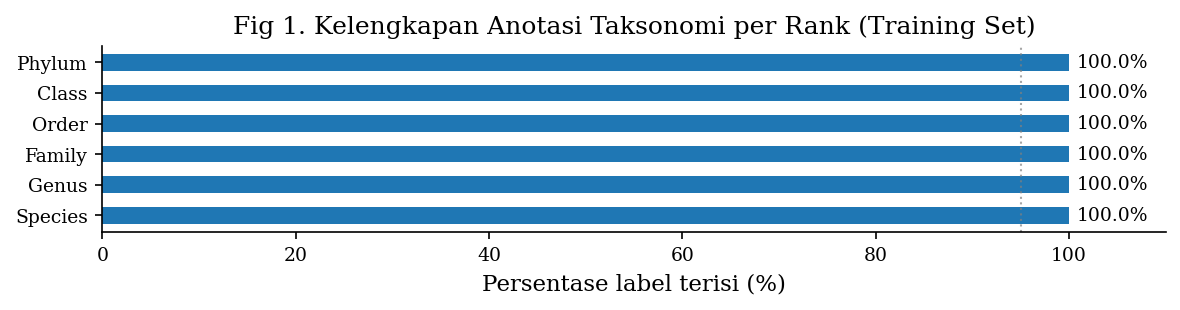

Rata-rata completeness: 100.0%


In [ ]:
#@title  ── Fig 1: Taxonomy completeness heatmap ─────────────────────────────────────
# Persentase label terisi (non-empty) per rank — indikator kualitas anotasi
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(HDF5_TRAIN, "r") as f:
    labels_train = f["labels"][:]   # (N, 6)

# Completeness: % label != 0 (0 = PAD/empty)
completeness = [(labels_train[:, r] != 0).mean() * 100 for r in range(len(ACTIVE_RANKS))]

fig, ax = plt.subplots(figsize=(8, 2.2))
colors = [PALETTE[0] if c >= 95 else PALETTE[1] if c >= 80 else PALETTE[2]
          for c in completeness]
bars = ax.barh(ACTIVE_RANKS[::-1], completeness[::-1], color=colors[::-1], height=0.55)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.set_xlim(0, 110)
ax.set_xlabel("Persentase label terisi (%)")
ax.set_title("Fig 1. Kelengkapan Anotasi Taksonomi per Rank (Training Set)")
ax.axvline(95, color="gray", linestyle=":", linewidth=1, alpha=0.7)
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig01_taxonomy_completeness.png")
plt.show()
print(f"Rata-rata completeness: {np.mean(completeness):.1f}%")


---
## 3. Eksplorasi Data

Visualisasikan distribusi taksonomi dan panjang sekuens dari file sumber sebelum pelatihan.


In [ ]:
#@title  ── Baca & parse taksonomi untuk eksplorasi ──────────────────────────────────
import pandas as pd
from tqdm import tqdm
from Preprocess import parse_silva_taxonomy

print("Membaca taxonomy TSV...")
tax_df = pd.read_csv(cfg.paths.silva_taxonomy, sep="\t", header=0)
tax_df.columns = ["feature_id", "taxon"]
print(f"Total entri: {len(tax_df):,}")

print("Parsing taksonomi (chunked)...")
CHUNK = 10_000
parsed_rows = []
for i in tqdm(range(0, len(tax_df), CHUNK), unit="chunk"):
    for _, row in tax_df.iloc[i:i+CHUNK].iterrows():
        p = parse_silva_taxonomy(row["taxon"])
        p["feature_id"] = row["feature_id"]
        parsed_rows.append(p)

parsed_df = pd.DataFrame(parsed_rows)
cols = ["feature_id","Domain","Phylum","Class","Order","Family","Genus","Species"]
parsed_df = parsed_df[[c for c in cols if c in parsed_df.columns]]
print(f"Phylum unik: {parsed_df['Phylum'].nunique()} | Genus unik: {parsed_df['Genus'].nunique()}")
parsed_df.head(3)


Membaca taxonomy TSV...
Total entri: 436,680
Parsing taksonomi (chunked)...


100%|██████████| 44/44 [00:24<00:00,  1.76chunk/s]


Phylum unik: 226 | Genus unik: 7958


,feature_id,Domain,Phylum,Class,Order,Family,Genus,Species
0,CP013078.2406498.2408039,Bacteria,Proteobacteria,Gammaproteobacteria,Burkholderiales,Alcaligenaceae,Bordetella,Bordetella_pertussis
1,CP015924.1224168.1225721,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella_enterica
2,CP003278.287486.289015,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella_enterica


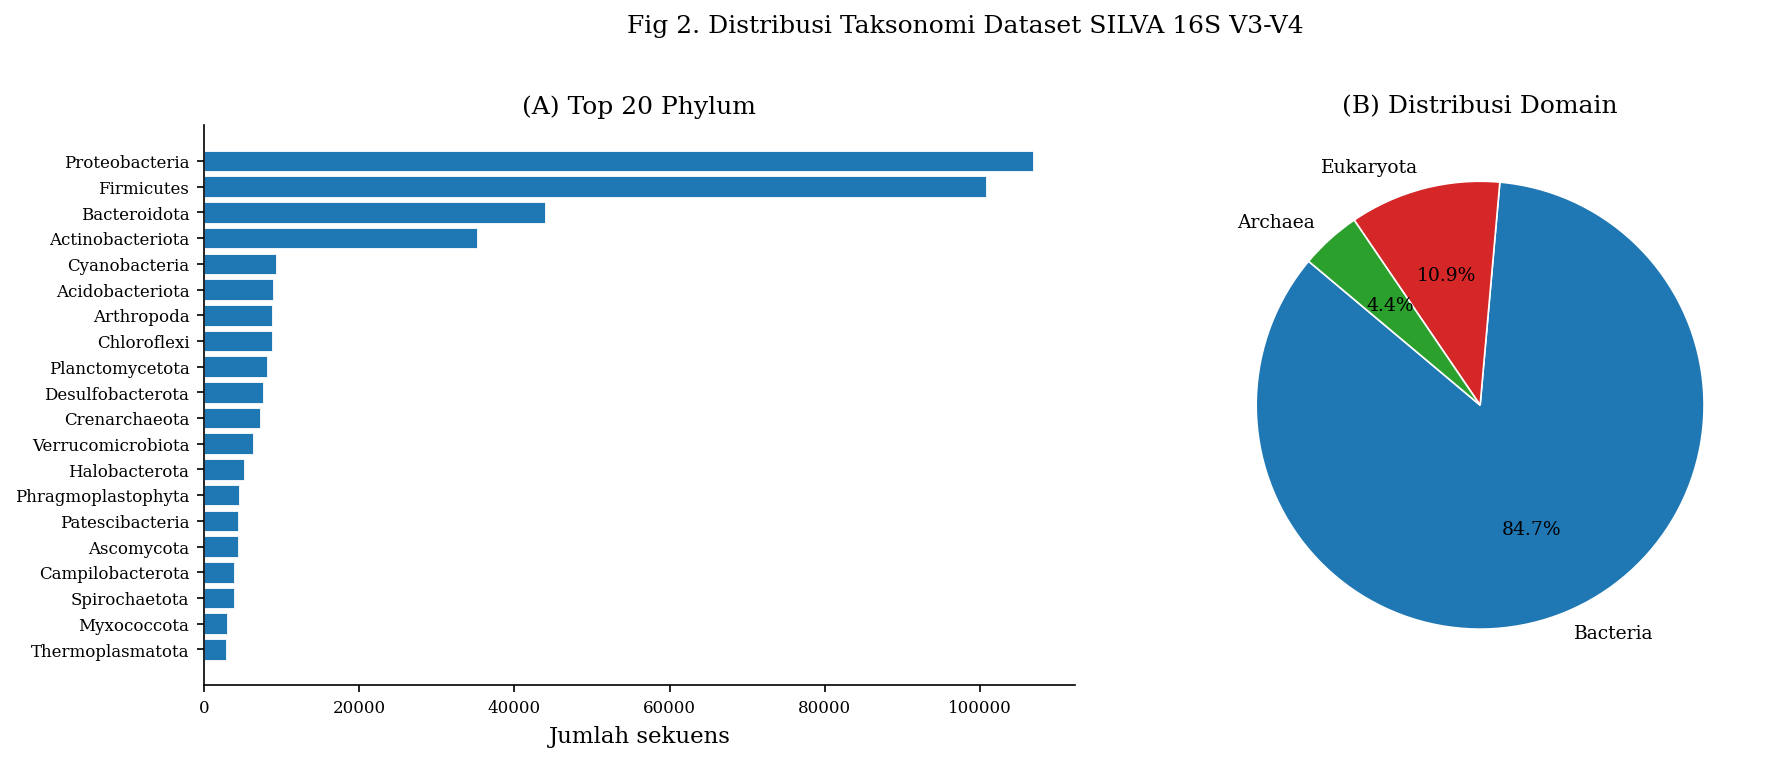

In [ ]:
#@title  ── Fig 2: Distribusi Phylum (top 20) + Domain ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: Top 20 Phylum ───────────────────────────────────────────────────
phylum_counts = (parsed_df["Phylum"]
                 .replace("", pd.NA).dropna()
                 .value_counts().head(20))
axes[0].barh(phylum_counts.index[::-1], phylum_counts.values[::-1],
             color=PALETTE[0], edgecolor="white", linewidth=0.4)
axes[0].set_title("(A) Top 20 Phylum")
axes[0].set_xlabel("Jumlah sekuens")
axes[0].tick_params(labelsize=8)

# ── Panel B: Distribusi Domain ──────────────────────────────────────────────
domain_counts = (parsed_df["Domain"]
                 .replace("", pd.NA).dropna()
                 .value_counts())
wedge_props = {"linewidth": 0.8, "edgecolor": "white"}
axes[1].pie(domain_counts.values, labels=domain_counts.index,
            autopct="%1.1f%%", startangle=140, colors=PALETTE[:len(domain_counts)],
            wedgeprops=wedge_props, textprops={"fontsize": 9})
axes[1].set_title("(B) Distribusi Domain")

fig.suptitle("Fig 2. Distribusi Taksonomi Dataset SILVA 16S V3-V4",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig02_taxonomy_distribution.png")
plt.show()


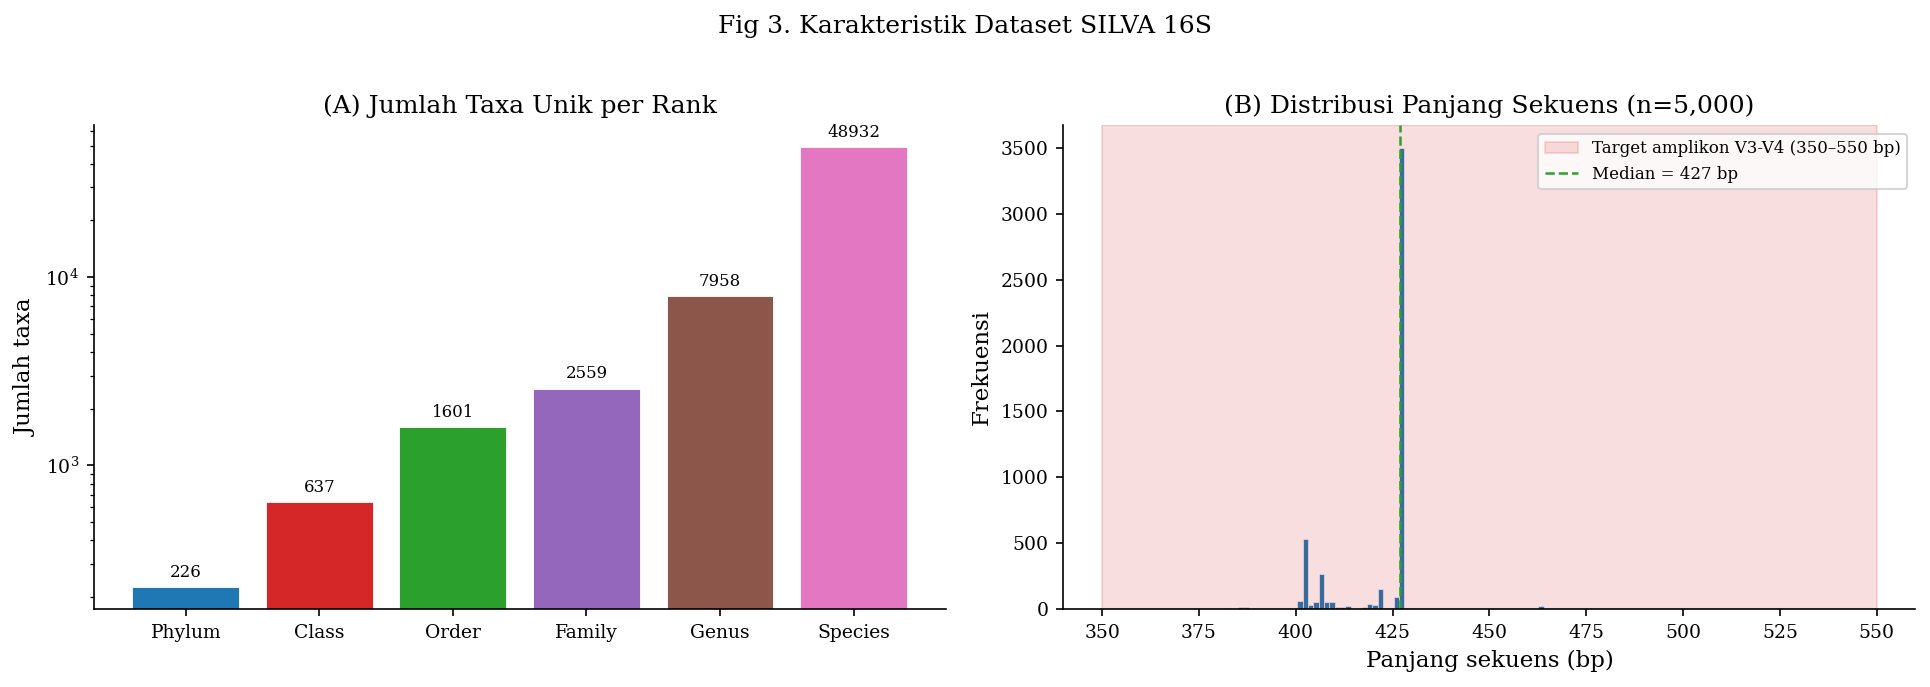

In [ ]:
#@title  ── Fig 3: Unique taxa count per rank + Sequence length distribution ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Panel A: Unique taxa per rank ────────────────────────────────────────────
EXPLORE_RANKS = ["Phylum","Class","Order","Family","Genus","Species"]
unique_counts = []
for r in EXPLORE_RANKS:
    if r in parsed_df.columns:
        n = parsed_df[r].replace("", pd.NA).dropna().nunique()
        unique_counts.append(n)
    else:
        unique_counts.append(0)

bars = axes[0].bar(EXPLORE_RANKS, unique_counts, color=PALETTE[:6],
                   edgecolor="white", linewidth=0.4)
axes[0].bar_label(bars, fmt="%d", padding=3, fontsize=8)
axes[0].set_title("(A) Jumlah Taxa Unik per Rank")
axes[0].set_ylabel("Jumlah taxa")
axes[0].set_yscale("log")

# ── Panel B: Sequence length distribution ────────────────────────────────────
seq_lengths = []
MAX_SAMPLE = 5_000
with open(cfg.paths.silva_fasta) as fh:
    cur_len = 0
    cnt = 0
    for line in fh:
        if cnt >= MAX_SAMPLE:
            break
        line = line.strip()
        if line.startswith(">"):
            if cur_len > 0:
                seq_lengths.append(cur_len)
                cnt += 1
            cur_len = 0
        else:
            cur_len += len(line)

axes[1].hist(seq_lengths, bins=60, color=PALETTE[0], edgecolor="white", linewidth=0.3)
axes[1].axvspan(350, 550, color=PALETTE[1], alpha=0.15,
                label="Target amplikon V3-V4 (350–550 bp)")
axes[1].axvline(np.median(seq_lengths), color=PALETTE[2], linestyle="--",
                linewidth=1.2, label=f"Median = {int(np.median(seq_lengths))} bp")
axes[1].set_xlabel("Panjang sekuens (bp)")
axes[1].set_ylabel("Frekuensi")
axes[1].set_title(f"(B) Distribusi Panjang Sekuens (n={len(seq_lengths):,})")
axes[1].legend(fontsize=8)

fig.suptitle("Fig 3. Karakteristik Dataset SILVA 16S", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig03_data_characteristics.png")
plt.show()


In [ ]:
#@title  ── Fig 4: Zipf distribution — label frequency before vs after roll-up ───────
# Fungsi ini membandingkan distribusi label Species sebelum dan sesudah
# taxonomic roll-up (long-tail mitigation via HierarchicalLabelEncoder).
from evaluate import plot_zipfian_distribution

# Data sebelum rollup: gunakan parsed_df yang sudah dibuat di Sec 2
# Jika preprocessing di-skip (HDF5 sudah ada), buat DataFrame sederhana dari label encoder
if "_df_before_rollup" in dir():
    _before = _df_before_rollup
elif "parsed_df" in dir():
    # parsed_df sudah tersedia di kernel (dibuat saat preprocessing)
    _before = parsed_df
else:
    # Fallback: gunakan hanya kolom Species agar panjang kolom seragam
    _before = pd.DataFrame(
        {"Species": [k for k in label_enc.label2idx["Species"].keys()
                     if k not in ("<PAD>", "<UNK>")]}
    )

# Data sesudah rollup = yang sudah ter-fit di label_enc (distribusi akhir)
# Gunakan frekuensi dari labels_train
with h5py.File(HDF5_TRAIN, "r") as f:
    _sp_idx = f["labels"][:, -1]  # kolom terakhir = Species
species_names = [label_enc.idx2label.get("Species", {}).get(int(i), "")
                 for i in _sp_idx[:50_000]]  # sample 50K
_after = pd.DataFrame({"Species": species_names})

plot_zipfian_distribution(
    before_df = _before,
    after_df  = _after,
    save_path = f"{cfg.paths.plot_dir}/fig04_zipf_rollup.png",
    rank      = "Species",
)
print("Fig 4 disimpan.")


Fig 4 disimpan.


---
## 4. Dataset & DataLoader

**Strategi data besar:**
- `TaxoHDF5Dataset`: baca HDF5 secara *lazy* — hanya slice yang diperlukan dimuat ke RAM
- `WeightedRandomSampler`: oversample kelas Genus langka untuk mengatasi imbalance
- `num_workers=0` untuk macOS/Jupyter (h5py tidak fork-safe); gunakan ≥ 4 di Linux server
- Demonstrasi tokenizer: k-mer k=6 vs BPE fallback via `DualTokenizer`


In [ ]:
#@title Dataset & DataLoader
import h5py, torch
import numpy as np
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm import tqdm
from dataset import KmerTokenizer

# ── TaxoHDF5Dataset: lazy-loading dari HDF5 ──────────────────────────────────
class TaxoHDF5Dataset(Dataset):
    """Lazy-loading Dataset dari HDF5 hasil preprocessing."""
    def __init__(self, hdf5_path: str):
        self.hdf5_path = hdf5_path
        self._handle = None
        with h5py.File(hdf5_path, "r") as f:
            self.n_samples = f["input_ids"].shape[0]

    def __len__(self): return self.n_samples

    def _get_handle(self):
        if self._handle is None:
            self._handle = h5py.File(self.hdf5_path, "r")
        return self._handle

    def __getitem__(self, idx):
        f   = self._get_handle()
        sid = f["seq_ids"][idx]
        return {
            "seq_ids":        sid.decode() if isinstance(sid, bytes) else str(sid),
            "input_ids":      torch.tensor(f["input_ids"][idx],      dtype=torch.long),
            "attention_mask": torch.tensor(f["attention_mask"][idx], dtype=torch.long),
            "labels":         torch.tensor(f["labels"][idx],         dtype=torch.long),
        }

    def __del__(self):
        if self._handle is not None:
            try: self._handle.close()
            except Exception: pass

def _collate_fn(batch):
    return {
        "seq_ids":        [x["seq_ids"]        for x in batch],
        "input_ids":      torch.stack([x["input_ids"]      for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "labels":         torch.stack([x["labels"]         for x in batch]),
    }

# ── Build DataLoaders ─────────────────────────────────────────────────────────
train_ds = TaxoHDF5Dataset(cfg.paths.hdf5_train)
val_ds   = TaxoHDF5Dataset(cfg.paths.hdf5_val)
print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")

# WeightedRandomSampler: weight berdasarkan Genus (rank idx 4)
print("Menghitung class weights (Genus, rank 4)...")
with h5py.File(cfg.paths.hdf5_train, "r") as f:
    genus_labels = f["labels"][:, 4]
class_counts  = np.bincount(genus_labels)
class_weights = 1.0 / (class_counts + 1e-6)
sample_wts    = torch.tensor([class_weights[l] for l in genus_labels], dtype=torch.float)
sampler = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

nw = cfg.data.dataloader_num_workers
base_kw = dict(pin_memory=False, collate_fn=_collate_fn, num_workers=nw)

train_dl = DataLoader(train_ds, batch_size=cfg.train.batch_size,
                      sampler=sampler, drop_last=True, **base_kw)
val_dl   = DataLoader(val_ds,   batch_size=cfg.train.batch_size * 2,
                      shuffle=False, drop_last=False, **base_kw)

print(f"Train batches: {len(train_dl):,} | Val batches: {len(val_dl):,}")

# ── Inspeksi satu batch ───────────────────────────────────────────────────────
sample_batch = next(iter(train_dl))
print("\nContoh batch:")
for k, v in sample_batch.items():
    if hasattr(v, "shape"):
        print(f"  {k:20s}: shape={tuple(v.shape)}, dtype={v.dtype}")
    else:
        print(f"  {k:20s}: {type(v).__name__}, len={len(v)}")


Train: 276,848 | Val: 30,761
Menghitung class weights (Genus, rank 4)...
Train batches: 17,303 | Val batches: 962

Contoh batch:
  seq_ids             : list, len=16
  input_ids           : shape=(16, 512), dtype=torch.int64
  attention_mask      : shape=(16, 512), dtype=torch.int64
  labels              : shape=(16, 6), dtype=torch.int64


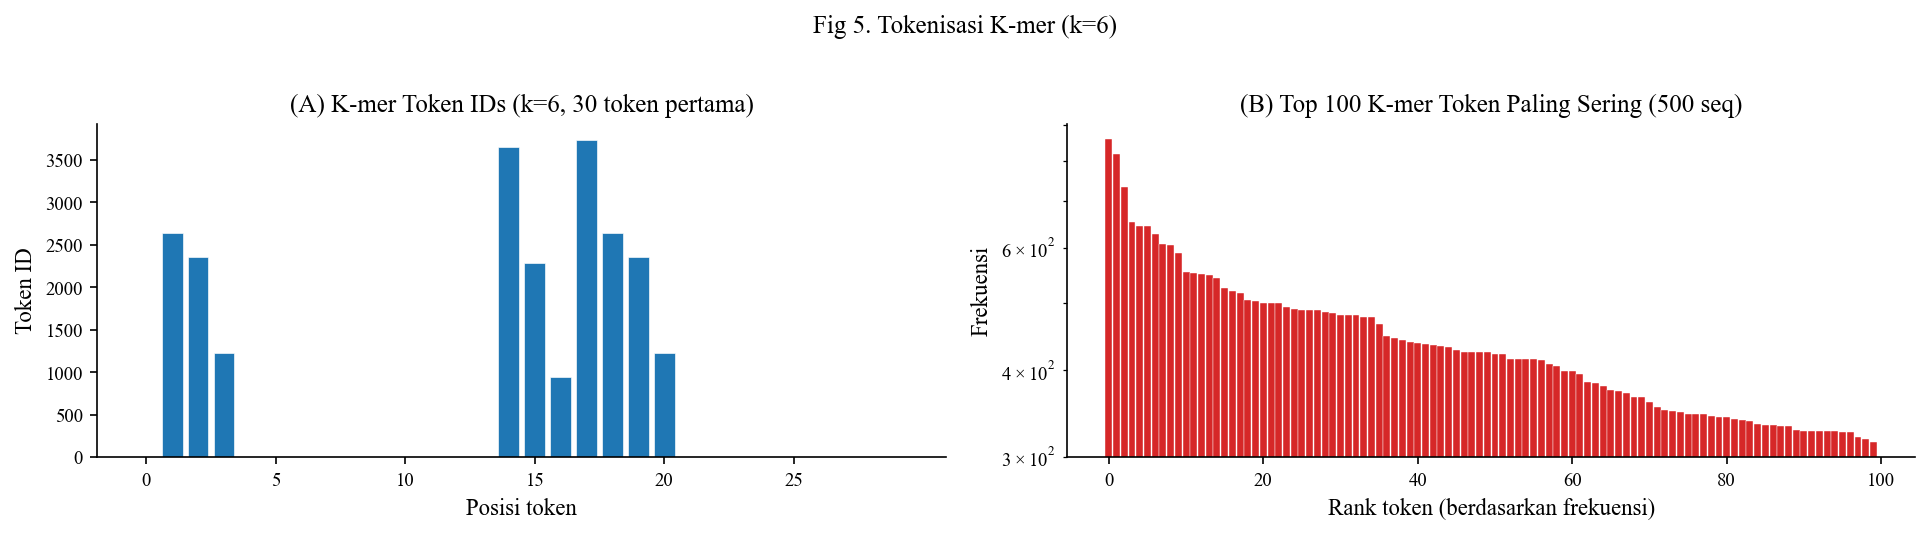

KmerTokenizer vocab_size: 4100 | seq_len: 512


In [ ]:
#@title  ── Fig 5: Demo tokenizer — k-mer token ID bar chart ─────────────────────────
from dataset import KmerTokenizer

tokenizer = KmerTokenizer(k=cfg.data.kmer_k, max_len=cfg.data.max_seq_len)
demo_seq  = "CCTACGGGNGGCWGCAGCCTACGGGNGGCWGCAGCCTACGGGNGGCWGCAG"
enc       = tokenizer.encode(demo_seq)

# Ambil hanya token non-PAD untuk visualisasi
token_ids = enc["input_ids"].numpy()
mask      = enc["attention_mask"].numpy().astype(bool)
active_ids = token_ids[mask][:30]  # tampilkan 30 token pertama

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Panel A: Token IDs sebagai bar chart
axes[0].bar(range(len(active_ids)), active_ids, color=PALETTE[0],
            edgecolor="white", linewidth=0.3, width=0.8)
axes[0].set_xlabel("Posisi token")
axes[0].set_ylabel("Token ID")
axes[0].set_title(f"(A) K-mer Token IDs (k={cfg.data.kmer_k}, 30 token pertama)")
axes[0].set_xticks(range(0, len(active_ids), 5))

# Panel B: Distribusi token ID untuk satu batch
with h5py.File(cfg.paths.hdf5_train, "r") as f:
    sample_ids  = f["input_ids"][:500].flatten()
    sample_mask = f["attention_mask"][:500].flatten().astype(bool)
active_sample = sample_ids[sample_mask]
# Histogram frekuensi token
uniq, counts = np.unique(active_sample, return_counts=True)
top_idx = np.argsort(counts)[::-1][:100]   # top 100 token terbanyak
axes[1].bar(range(100), counts[top_idx], color=PALETTE[1],
            edgecolor="white", linewidth=0.2, width=0.9)
axes[1].set_xlabel("Rank token (berdasarkan frekuensi)")
axes[1].set_ylabel("Frekuensi")
axes[1].set_title("(B) Top 100 K-mer Token Paling Sering (500 seq)")
axes[1].set_yscale("log")

fig.suptitle(f"Fig 5. Tokenisasi K-mer (k={cfg.data.kmer_k})", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig05_tokenizer.png")
plt.show()
print(f"KmerTokenizer vocab_size: {tokenizer.vocab_size} | seq_len: {tokenizer.max_len}")


---
## 5. Hyperbolic Taxonomy GNN

`HyTaxGNN` belajar embedding Poincaré untuk setiap node takson dalam taxonomy graph.
Properti utama Poincaré ball: jarak geodesik meningkat secara eksponensial menuju tepi bola,
memungkinkan representasi hierarki yang efisien dalam dimensi rendah.

**Fungsi `build_taxonomy_graph()`** mengembalikan 4-tuple:
`(num_nodes, edge_index, node2idx, leaf_node_ids)`
dimana `leaf_node_ids` digunakan untuk OOD detection (Species-level nodes).


In [ ]:
#@title Hyperbolic Taxo GNN
import pickle, torch
from hyperbolic import PoincareBall, HyTaxGNN, build_taxonomy_graph

DEVICE = torch.device(cfg.device)

# ── Build taxonomy graph ─────────────────────────────────────────────────────
# Gunakan build_taxonomy_graph() dari hyperbolic.py (4-tuple return)
# Jika parsed_df tersedia gunakan co-occurrence edges; jika tidak, fallback.
print("Membangun taxonomy graph...")
if "parsed_df" in dir() and parsed_df is not None:
    num_nodes, edge_index, node2idx, leaf_node_ids = build_taxonomy_graph(
        label_encoder=label_enc, df=parsed_df, device=cfg.device
    )
else:
    num_nodes, edge_index, node2idx, leaf_node_ids = build_taxonomy_graph(
        label_encoder=label_enc, df=None, device=cfg.device
    )

edge_index    = edge_index.to(DEVICE)
leaf_node_ids = leaf_node_ids.to(DEVICE)

print(f"  num_nodes      : {num_nodes:,}")
print(f"  num_edges      : {edge_index.shape[1]:,}")
print(f"  leaf_node_ids  : {len(leaf_node_ids):,} Species nodes")

# Simpan taxonomy graph ke pickle untuk reuse
tax_graph = {
    "edge_index":    edge_index.cpu(),
    "num_nodes":     num_nodes,
    "node2idx":      node2idx,
    "leaf_node_ids": leaf_node_ids.cpu(),
}
Path(cfg.paths.taxonomy_graph).parent.mkdir(parents=True, exist_ok=True)
with open(cfg.paths.taxonomy_graph, "wb") as f:
    pickle.dump(tax_graph, f)
print(f"  Taxonomy graph disimpan: {cfg.paths.taxonomy_graph}")


Membangun taxonomy graph...
  num_nodes      : 7,954
  num_edges      : 11,836,568
  leaf_node_ids  : 1,499 Species nodes
  Taxonomy graph disimpan: /content/drive/MyDrive/RKI/taxograph-bert-1/data/processed/taxonomy_graph.pkl


In [ ]:
#@title  ── Demo HyTaxGNN — forward pass ─────────────────────────────────────────────
# ── Seed untuk reproducibility ───────────────────────────────────────────────
# Tanpa seed, embedding pre-training selalu berbeda setiap sesi karena
# nn.Embedding diinisialisasi acak. Seed ini membuat norm & Fig 6 reproducible.
import random, numpy as np
_SEED = cfg.data.random_seed  # default 42
random.seed(_SEED)
np.random.seed(_SEED)
torch.manual_seed(_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(_SEED)

gnn = HyTaxGNN(
    num_nodes  = num_nodes,
    in_dim     = 32,
    hidden_dim = cfg.model.hgnn_hidden_dim,
    n_layers   = cfg.model.hgnn_num_layers,
    curvature  = cfg.model.poincare_curvature,
    dropout    = cfg.model.hgnn_dropout,
).to(DEVICE)

with torch.no_grad():
    node_emb = gnn(edge_index)   # (N, hidden_dim)

norm_vals = node_emb.norm(dim=-1).cpu().numpy()
print(f"HyTaxGNN output shape: {node_emb.shape}")
print(f"  Norm rata-rata : {norm_vals.mean():.4f}  "
      f"(harus < 1/√c = {1/cfg.model.poincare_curvature**0.5:.2f})")
print(f"  Norm max       : {norm_vals.max():.4f}")
print()
print("ℹ️  Ini adalah embedding PRE-TRAINING (sebelum dilatih).")
print("   Semua node berada dekat origin karena inisialisasi acak (std=0.01).")
print("   Hierarki (Phylum di pusat, Species di tepi) akan muncul SETELAH training.")


HyTaxGNN output shape: torch.Size([7954, 128])
  Norm rata-rata : 0.0882  (harus < 1/√c = 1.00)
  Norm max       : 0.0882


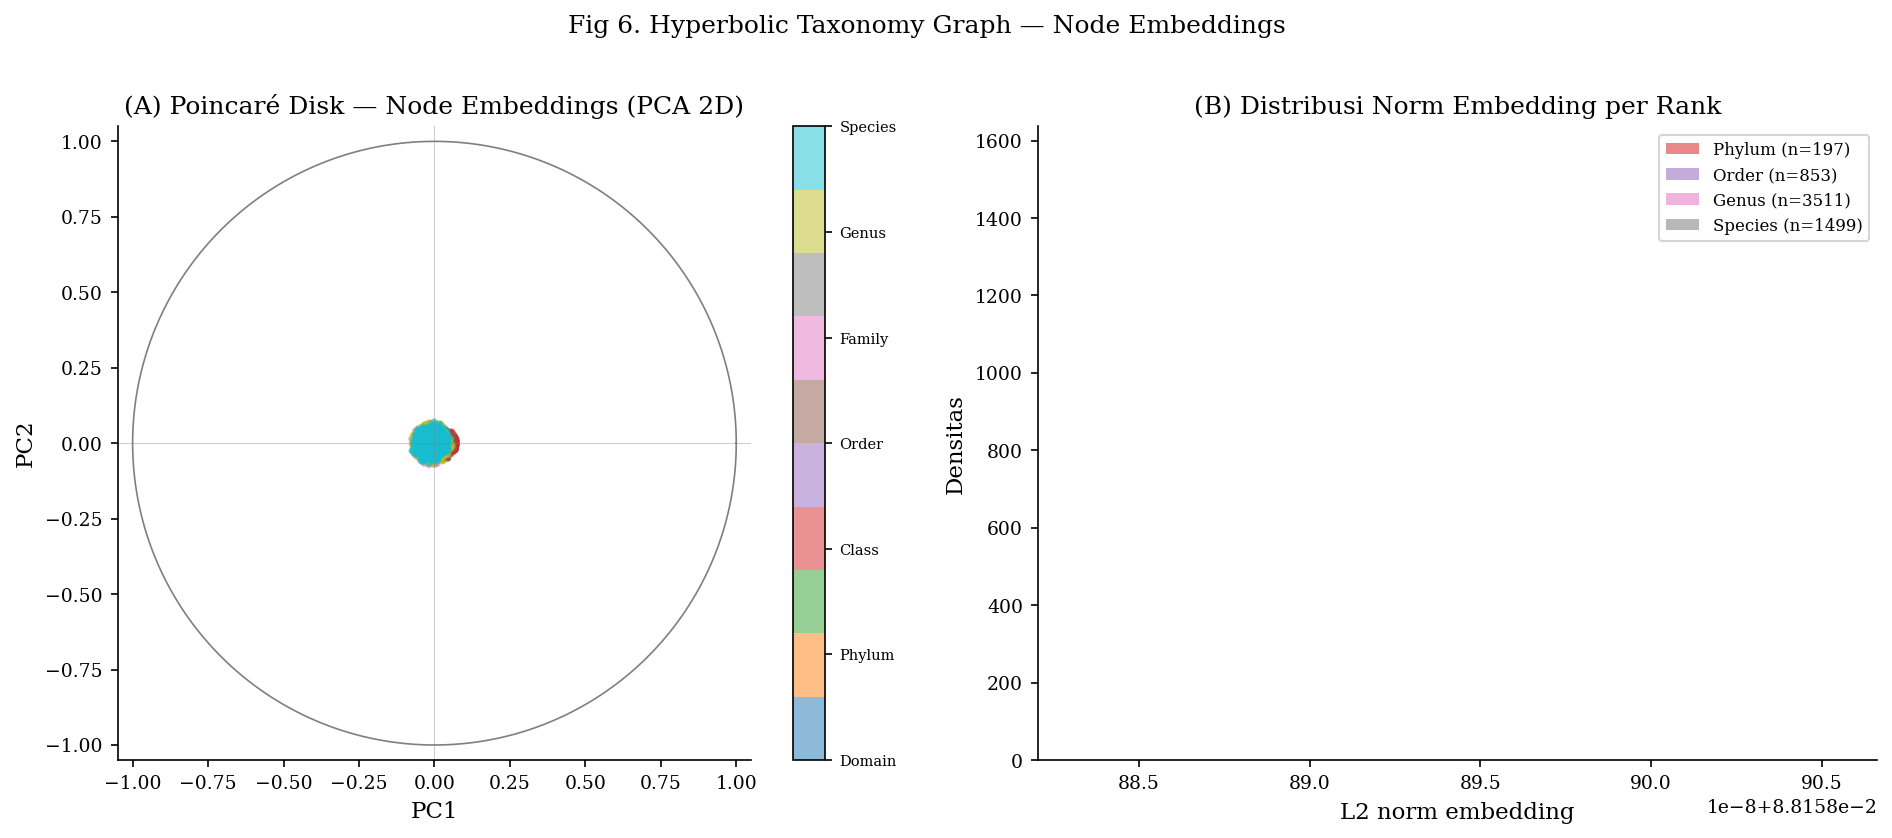

In [ ]:
#@title ── Fig 6: Poincaré disk (PCA 2D) + norm histogram ───────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# CATATAN: Sel ini memvisualisasikan embedding PRE-TRAINING (sebelum dilatih).
#
# • Semua norm sangat kecil (~0.0001) karena embedding baru diinisialisasi
#   dekat origin — ini NORMAL dan BENAR untuk kondisi pre-training.
#
# • Posisi Phylum/Species pada plot adalah noise acak, BUKAN hasil pembelajaran.
#   Hierarki nyata (Phylum dekat pusat, Species dekat tepi bola Poincaré)
#   hanya akan muncul setelah model selesai dilatih (Fig 6 post-training).
#
# • Jika plot tampak berbeda antar sesi, pastikan sel seed di atas sudah dijalankan.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA

emb_cpu = node_emb.detach().cpu().numpy()

# Warnai node berdasarkan kedalaman hierarki (Domain=0 ... Species=5)
# node2idx: {"rank:label" → global_id}
depth_map  = {"Domain": 0, "Phylum": 1, "Class": 2,
              "Order": 3, "Family": 4, "Genus": 5, "Species": 6}
node_depths = np.zeros(num_nodes, dtype=int)
for key, gid in node2idx.items():
    rank = key.split(":")[0]
    node_depths[gid] = depth_map.get(rank, 3)

# PCA 2D (atau gunakan langsung dim 0,1 jika hidden_dim=2)
if emb_cpu.shape[1] > 2:
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(emb_cpu)
else:
    emb_2d = emb_cpu

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel A: Poincaré disk
theta = np.linspace(0, 2 * np.pi, 300)
axes[0].plot(np.cos(theta), np.sin(theta), "k-", linewidth=0.8, alpha=0.5)
axes[0].axhline(0, color="gray", lw=0.5, alpha=0.4)
axes[0].axvline(0, color="gray", lw=0.5, alpha=0.4)
cmap = plt.get_cmap("tab10")
scat = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1],
                       c=node_depths, cmap=cmap, s=5, alpha=0.5,
                       vmin=0, vmax=6)
cb = plt.colorbar(scat, ax=axes[0])
cb.set_ticks([0, 1, 2, 3, 4, 5, 6])
cb.set_ticklabels(["Domain","Phylum","Class","Order","Family","Genus","Species"], fontsize=7)
axes[0].set_xlim(-1.05, 1.05)
axes[0].set_ylim(-1.05, 1.05)
axes[0].set_aspect("equal")
axes[0].set_title("(A) Poincaré Disk — Node Embeddings (PCA 2D)\n"
                  "[PRE-TRAINING: posisi belum merepresentasikan hierarki]")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Panel B: Distribusi norm per kedalaman
for d, rank_name in [(1,"Phylum"),(3,"Order"),(5,"Genus"),(6,"Species")]:
    mask_d = node_depths == d
    if mask_d.sum() > 0:
        vals_d = norm_vals[mask_d]
        use_density = (vals_d.max() - vals_d.min()) > 1e-4
        axes[1].hist(vals_d, bins=30, alpha=0.55,
                     label=f"{rank_name} (n={mask_d.sum()})",
                     color=PALETTE[d % len(PALETTE)], density=use_density)
axes[1].set_xlabel("L2 norm embedding")
axes[1].set_ylabel("Densitas")
axes[1].set_title("(B) Distribusi Norm Embedding per Rank\n"
                  "[Semua norm kecil = normal untuk pre-training]")
axes[1].legend(fontsize=8)

fig.suptitle("Fig 6. Hyperbolic Taxonomy Graph — Node Embeddings (Pre-Training)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig06_poincare_disk.png")
plt.show()


In [ ]:
#@title  ── [Diagnostik] Fig 6 zoom — lihat struktur embedding sebelum training ────────
# Sel ini hanya untuk inspeksi; Fig 6 asli (skala ±1.05) TIDAK berubah.
# Jalankan segera setelah sel Fig 6 di atas.

# Auto-range: 2× norm max agar semua titik terlihat
_r = max(float(norm_vals.max()) * 2.0, 1e-5)

fig_z, axes_z = plt.subplots(1, 2, figsize=(12, 5))

# ── Panel A: Poincaré disk di-zoom ────────────────────────────────────────────
# Lingkaran referensi = 2× norm max (batas visualisasi zoom)
circ_ref = plt.Circle((0, 0), _r, fill=False, color="gray",
                       linewidth=0.8, linestyle="--", alpha=0.6,
                       label=f"2× norm_max ({_r:.5f})")
axes_z[0].add_patch(circ_ref)

cmap_z = plt.get_cmap("tab10")
scat_z = axes_z[0].scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=node_depths, cmap=cmap_z, s=8, alpha=0.6, vmin=0, vmax=6,
)
cb_z = plt.colorbar(scat_z, ax=axes_z[0])
cb_z.set_ticks([0, 1, 2, 3, 4, 5, 6])
cb_z.set_ticklabels(
    ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"], fontsize=7
)

axes_z[0].set_xlim(-_r, _r)
axes_z[0].set_ylim(-_r, _r)
axes_z[0].set_aspect("equal")
axes_z[0].set_title(
    f"Zoom: ±{_r:.5f}  |  norm_max={norm_vals.max():.5f}\n"
    f"(pre-training — semua embedding dekat origin)"
)
axes_z[0].legend(fontsize=7, loc="upper right")

# ── Panel B: Distribusi norm (count) ───────────────────────────────────────────────
for d, rank_name in [(1, "Phylum"), (3, "Order"), (5, "Genus"), (6, "Species")]:
    mask_d = node_depths == d
    if mask_d.sum() > 0:
        axes_z[1].hist(
            norm_vals[mask_d], bins=40, alpha=0.6,
            label=f"{rank_name} (n={mask_d.sum()})",
            color=PALETTE[d % len(PALETTE)],
        )

axes_z[1].set_xlabel("L2 norm embedding")
axes_z[1].set_ylabel("Count")
axes_z[1].set_title("(B) Distribusi Norm Embedding (pre-training)")
axes_z[1].legend(fontsize=8)

fig_z.suptitle(
    "Fig 6-zoom. Diagnostic — Pre-training Embeddings (skala diperbesar)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
_zoom_path = f"{cfg.paths.plot_dir}/fig06_poincare_disk_zoom.png"
plt.savefig(_zoom_path)
plt.show()
print(f"  _r (zoom radius) = {_r:.6f}  |  norm_max = {norm_vals.max():.6f}")

---
## 6. Build Model — `taxograph_bert.py`

**Arsitektur TaxoGraph-BERT:**

| Komponen | Detail |
|---|---|
| Backbone DNA-BERT | `zhihan1996/DNABERT-2-117M` (LoRA r=16, α=32) |
| HyTaxGNN | GNN di Poincaré ball — pre-trained di Phase 1 |
| Hierarchical Classifiers | 6 head linear (satu per rank) |
| OOD Detector | Energy-based score + threshold kalibrasi |

> **PENTING:** `build_model()` membutuhkan 4 argumen: `cfg, label_enc, edge_index, leaf_node_ids`
> Forward pass: `model(input_ids, attention_mask)` — **tanpa** `edge_index=` kwarg (disimpan sebagai buffer).
> Output key: `out["hyp_emb"]` (bukan `out["z_hyp"]`).


In [ ]:
#@title Build Model

# ── Force fresh reimport so Drive edits are always picked up ─────────────────
import sys
for _m in list(sys.modules):
    if _m in ("taxograph_bert", "hyperbolic"):
        del sys.modules[_m]

from taxograph_bert import TaxoGraphBERT, build_model

print("Membangun TaxoGraph-BERT...")
# build_model already calls model.to(cfg.device) internally
model = build_model(cfg, label_enc, edge_index, leaf_node_ids)
model.eval()
print("Model berhasil dibangun.\n")

# ── Unwrap DataParallel untuk akses atribut submodul ─────────────────────────
raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model

# ── Parameter breakdown ───────────────────────────────────────────────────────
def _count_params(module):
    total     = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable

rows = []
for name, sub in [
    ("DNA-BERT Backbone (LoRA)",       raw_model.seq_encoder),
    ("HyTaxGNN",                       raw_model.hytaxgnn),
    ("Hierarchical Classifiers",       raw_model.classifier),
    ("OOD Head",                       raw_model.ood_head),
]:
    t, tr = _count_params(sub)
    rows.append({"Komponen": name, "Total Params": t, "Trainable": tr,
                 "% Trainable": f"{tr/max(t,1)*100:.1f}%"})

total_all, train_all = _count_params(model)
rows.append({"Komponen": "─── TOTAL ───",
             "Total Params": total_all, "Trainable": train_all,
             "% Trainable": f"{train_all/max(total_all,1)*100:.1f}%"})

df_params = pd.DataFrame(rows)
df_params["Total Params"] = df_params["Total Params"].apply(lambda x: f"{x:,}")
df_params["Trainable"]     = df_params["Trainable"].apply(lambda x: f"{x:,}")
display(df_params)


Membangun TaxoGraph-BERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[DNASequenceEncoder] BertEncoder.rebuild_alibi_tensor berhasil di-patch.


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNABERT-2-117M
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[DNASequenceEncoder] flash_attn dinon-aktifkan di 'transformers_modules.zhihan1996.DNABERT_hyphen_2_hyphen_117M.7bce263b15377fc15361f52cfab88f8b586abda0.bert_layers'.
[DNASequenceEncoder] DNABERT-2 berhasil dimuat (mode='pretrain').
trainable params: 589,824 || all params: 117,658,368 || trainable%: 0.5013
[build_model] Single GPU terdeteksi (cuda:0)
[build_model] Total params: 118,875,230 | Trainable: 1,806,685 (1.5%)
Model berhasil dibangun.



,Komponen,Total Params,Trainable,% Trainable
0,DNA-BERT Backbone (LoRA),"117,658,368","589,824",0.5%
1,HyTaxGNN,"551,168","551,168",100.0%
2,Hierarchical Classifiers,"567,261","567,261",100.0%
3,OOD Head,1,0,0.0%
4,─── TOTAL ───,"118,875,230","1,806,685",1.5%


In [ ]:
#@title  ── Demo forward pass & verifikasi output shapes ─────────────────────────────
batch = next(iter(val_dl))
with torch.no_grad():
    out = model(
        batch["input_ids"].to(DEVICE),
        batch["attention_mask"].to(DEVICE),
    )

print("Output shapes:")
print(f"  hyp_emb       : {out['hyp_emb'].shape}    # (B, poincare_dim)")
for i, lg in enumerate(out["logits"]):
    print(f"  logits[{i}]      : {str(lg.shape):<25} # {ACTIVE_RANKS[i]}")
print(f"  ood_score     : {out['ood_score'].shape}")
print(f"  is_ood        : {out['is_ood'].shape}  # bool")
print(f"  topk_leaf_ids : {out['topk_leaf_ids'].shape}")


Output shapes:
  hyp_emb       : torch.Size([32, 128])    # (B, poincare_dim)
  logits[0]      : torch.Size([32, 199])     # Phylum
  logits[1]      : torch.Size([32, 512])     # Class
  logits[2]      : torch.Size([32, 854])     # Order
  logits[3]      : torch.Size([32, 1386])    # Family
  logits[4]      : torch.Size([32, 3513])    # Genus
  logits[5]      : torch.Size([32, 1501])    # Species
  ood_score     : torch.Size([32])
  is_ood        : torch.Size([32])  # bool
  topk_leaf_ids : torch.Size([32, 5])


---
## 7. Training — `trainer.py`

Pelatihan dibagi dua fase:

**Phase 1 — Pre-train HyTaxGNN** (`pretrain_hgnn_epochs=200`)
- Hanya HyTaxGNN yang di-update; backbone DNA-BERT di-freeze
- Loss: Poincaré triplet margin + hyperbolic centroid
- Checkpoint: `checkpoints/phase1_hgnn.pt` → key `"hgnn_state"`

**Phase 2 — Joint Fine-tuning** (`max_epochs=100`)
- Semua komponen trainable (backbone via LoRA)
- Loss: Cross-entropy per rank × 6 + Poincaré regularization
- Early stopping: `patience=10` berdasarkan val F1-macro
- OOD kalibrasi otomatis di akhir `trainer.train()`
- Checkpoint: `checkpoints/<name>_best.pt` → key `"model_state"`

> **API Penting:** `Trainer(model, train_dl, val_dl, cfg)` — **4 argumen**, tanpa `label_enc`


In [ ]:
from trainer import Trainer
from pathlib import Path

#@title  ── Phase 1: Pre-train HyTaxGNN ──────────────────────────────────────────────
phase1_ckpt = Path(cfg.paths.checkpoint_dir) / "phase1_hgnn.pt"

# Unwrap DataParallel untuk akses submodul
raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model

if phase1_ckpt.exists():
    print(f"✓ Phase 1 checkpoint ditemukan: {phase1_ckpt}")
    # weights_only=False diperlukan karena checkpoint menyimpan objek cfg (dataclass)
    ckpt = torch.load(phase1_ckpt, map_location=DEVICE, weights_only=False)
    raw_model.hytaxgnn.load_state_dict(ckpt["hgnn_state"])
    print(f"  HyTaxGNN dimuat dari checkpoint (epoch {ckpt.get('epoch', '?')})")
else:
    print("Phase 1: Pre-train HyTaxGNN...")
    trainer = Trainer(model, train_dl, val_dl, cfg)
    trainer.setup_optimizers()
    trainer.phase1_pretrain_hgnn()
    print("✓ Phase 1 selesai.")


2026-05-11 15:26:01.391 | INFO     | trainer:_init_csv:219 - CSV log: /content/drive/MyDrive/RKI/taxograph-bert-1/outputs/metrics/taxograph_bert_v1_train_log.csv
2026-05-11 15:26:01.394 | INFO     | trainer:_build_optimizers:359 - Optimizer: 162 Transformer params (lr=3e-05) + 40 other params (lr=0.0005)
2026-05-11 15:26:01.395 | INFO     | trainer:phase1_pretrain_hgnn:236 - === PHASE 1: Pre-training HyTaxGNN ===


Phase 1: Pre-train HyTaxGNN...


2026-05-11 15:26:02.263 | INFO     | trainer:phase1_pretrain_hgnn:268 - Phase 1: submodul non-HyTaxGNN dioffload ke CPU (VRAM freed).


Phase 1 — HyTaxGNN Pre-train:   0%|          | 0/200 [00:00<?, ?epoch/s]

2026-05-11 15:27:31.483 | INFO     | trainer:phase1_pretrain_hgnn:309 - Phase 1 selesai. Checkpoint: /content/drive/MyDrive/RKI/taxograph-bert-1/outputs/checkpoints/phase1_hgnn.pt
2026-05-11 15:27:31.624 | INFO     | trainer:phase1_pretrain_hgnn:318 - Phase 1: submodul dikembalikan ke device semula.


✓ Phase 1 selesai.


In [ ]:
#@title  ── Phase 2: Joint Fine-tuning ────────────────────────────────────────────────
import glob

# ── Cek apakah training sudah selesai sebelumnya ─────────────────────────────
existing_latest = sorted(glob.glob(f"{cfg.paths.checkpoint_dir}/*_latest.pt"))
_training_already_complete = False
if existing_latest:
    _ckpt_peek = torch.load(existing_latest[-1], map_location=DEVICE, weights_only=False)
    _training_already_complete = _ckpt_peek.get("training_complete", False)
    del _ckpt_peek

if _training_already_complete:
    # Training sudah selesai di sesi sebelumnya — langsung muat best checkpoint
    print("✓ Training sudah selesai di sesi sebelumnya.")
    best_ckpts = sorted(glob.glob(f"{cfg.paths.checkpoint_dir}/*_best.pt"))
    if best_ckpts:
        _best_ckpt_path = best_ckpts[-1]
        print(f"  Memuat best checkpoint: {_best_ckpt_path}")
        raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model
        ckpt = torch.load(_best_ckpt_path, map_location=DEVICE, weights_only=False)
        raw_model.load_state_dict(ckpt["model_state"])
        print(f"  Model dimuat (epoch {ckpt.get('epoch','?')}, "
              f"val F1-macro={ckpt.get('val_f1_macro', 0):.4f})")
    else:
        print("⚠ Best checkpoint tidak ditemukan; gunakan model state terkini.")
else:
    # Training belum selesai (fresh start atau terputus di tengah jalan).
    # Trainer.train() menangani kedua kasus via resume_from_latest():
    #   - _latest.pt ditemukan, training_complete=False → restore bobot, optimizer,
    #     scheduler, scaler, best_val_f1, patience_ctr, global_step, lanjut dari
    #     epoch terakhir yang selesai (tidak inisialisasi ulang apapun)
    #   - tidak ada checkpoint → fresh start dari epoch 1
    print("Phase 2: Memulai / melanjutkan joint fine-tuning...")
    trainer = Trainer(model, train_dl, val_dl, cfg)
    trainer.setup_optimizers()
    # train() memanggil resume_from_latest() secara internal — jangan pass
    # start_epoch manual agar auto-resume berjalan dari _latest.pt
    trainer.train()   # OOD kalibrasi otomatis dijalankan di akhir train()

    # Setelah training selesai, muat bobot terbaik untuk evaluasi
    # (hanya bobot — optimizer/scheduler tidak diperlukan lagi)
    best_ckpts = sorted(glob.glob(f"{cfg.paths.checkpoint_dir}/*_best.pt"))
    raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model
    if best_ckpts:
        _best_ckpt_path = best_ckpts[-1]
        ckpt = torch.load(_best_ckpt_path, map_location=DEVICE, weights_only=False)
        raw_model.load_state_dict(ckpt["model_state"])
        print(f"✓ Phase 2 selesai — best checkpoint dimuat: {_best_ckpt_path}")
        print(f"  epoch={ckpt.get('epoch','?')}, val F1-macro={ckpt.get('val_f1_macro',0):.4f}")
    else:
        print("⚠ Tidak ada checkpoint tersimpan; gunakan model state terkini.")

model.eval()
print("Model siap untuk evaluasi.")


2026-05-11 15:27:56.424 | INFO     | trainer:_init_csv:219 - CSV log: /content/drive/MyDrive/RKI/taxograph-bert-1/outputs/metrics/taxograph_bert_v1_train_log.csv
2026-05-11 15:27:56.427 | INFO     | trainer:_build_optimizers:359 - Optimizer: 162 Transformer params (lr=3e-05) + 40 other params (lr=0.0005)
2026-05-11 15:27:56.428 | INFO     | trainer:train:377 - === PHASE 2: Joint Fine-tuning ===
2026-05-11 15:27:56.431 | INFO     | trainer:resume_from_latest:670 - Resume: tidak ada checkpoint ditemukan — mulai dari awal.
2026-05-11 15:27:56.440 | INFO     | trainer:_init_csv:219 - CSV log: /content/drive/MyDrive/RKI/taxograph-bert-1/outputs/metrics/taxograph_bert_v1_train_log.csv


Phase 2: Joint fine-tuning...


Epoch:   0%|          | 0/100 [00:00<?, ?epoch/s]

  Train Epoch 1:   0%|          | 0/17303 [00:00<?, ?batch/s]

---
## 8. Evaluasi Post-Training

Visualisasi kurva training, performa per rank, kalibrasi, dan confusion matrix.


In [ ]:
#@title ── [Restore Session] Muat ulang model & data untuk analisis
# Jalankan jika sesi baru dimulai tanpa re-training.
# Memulihkan: label_enc, edge_index, leaf_node_ids, model (dari checkpoint), val_dl.
# AMAN: tidak mengubah bobot — hanya membaca dari file.
# Prasyarat: sel Konfigurasi (Section 1) harus sudah dijalankan (cfg tersedia).
import sys, pickle, glob as _glob, h5py, torch
from pathlib import Path
from torch.utils.data import DataLoader

assert "cfg" in dir(), "cfg tidak ada! Jalankan dulu sel Konfigurasi (Section 1)."
DEVICE = torch.device(cfg.device)

# 1. Label encoder
from Preprocess import HierarchicalLabelEncoder
label_enc    = HierarchicalLabelEncoder.load(cfg.paths.label_encoder)
ACTIVE_RANKS = label_enc.ranks
print(f"\u2713 label_enc loaded: {len(ACTIVE_RANKS)} ranks")

# 2. Taxonomy graph
with open(cfg.paths.taxonomy_graph, "rb") as _f:
    _tax = pickle.load(_f)
edge_index    = _tax["edge_index"].to(DEVICE)
leaf_node_ids = _tax["leaf_node_ids"].to(DEVICE)
node2idx      = _tax["node2idx"]
num_nodes     = _tax["num_nodes"]
print(f"\u2713 Taxonomy graph: {num_nodes:,} nodes")

# 3. Build model & load best checkpoint
for _m in list(sys.modules):
    if _m in ("taxograph_bert", "hyperbolic"): del sys.modules[_m]
from taxograph_bert import build_model
model     = build_model(cfg, label_enc, edge_index, leaf_node_ids)
raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model
_ckpts = sorted(_glob.glob(f"{cfg.paths.checkpoint_dir}/*_best.pt"))
if not _ckpts:
    _ckpts = sorted(_glob.glob(f"{cfg.paths.checkpoint_dir}/*_latest.pt"))
if _ckpts:
    _ckpt = torch.load(_ckpts[-1], map_location=DEVICE, weights_only=False)
    raw_model.load_state_dict(_ckpt["model_state"])
    print(f"\u2713 Checkpoint: {Path(_ckpts[-1]).name}  epoch={_ckpt.get('epoch','?')}  best_val_f1={_ckpt.get('best_val_f1',0):.4f}")
else:
    print(f"\u26a0 Tidak ada checkpoint di {cfg.paths.checkpoint_dir}")
model.eval()

# 4. Rebuild val_dl
class _DS(torch.utils.data.Dataset):
    def __init__(self, p):
        self.p=p; self._h=None
        with h5py.File(p, "r") as f: self.n = f["input_ids"].shape[0]
    def __len__(self): return self.n
    def _hdl(self):
        if self._h is None: self._h = h5py.File(self.p, "r")
        return self._h
    def __getitem__(self, i):
        f = self._hdl(); s = f["seq_ids"][i]
        return {"seq_ids": s.decode() if isinstance(s, bytes) else str(s),
                "input_ids":      torch.tensor(f["input_ids"][i],      dtype=torch.long),
                "attention_mask": torch.tensor(f["attention_mask"][i], dtype=torch.long),
                "labels":         torch.tensor(f["labels"][i],         dtype=torch.long)}
    def __del__(self):
        if getattr(self, "_h", None):
            try: self._h.close()
            except: pass
def _col(b):
    return {"seq_ids": [x["seq_ids"] for x in b],
            "input_ids":      torch.stack([x["input_ids"]      for x in b]),
            "attention_mask": torch.stack([x["attention_mask"] for x in b]),
            "labels":         torch.stack([x["labels"]         for x in b])}
_vds   = _DS(cfg.paths.hdf5_val)
val_dl = DataLoader(_vds, batch_size=cfg.train.batch_size * 2, shuffle=False,
                    drop_last=False, num_workers=cfg.data.dataloader_num_workers,
                    collate_fn=_col)
print(f"\u2713 val_dl: {len(_vds):,} samples  {len(val_dl):,} batches")
print("\n\u2705 Sesi analysis siap! Lanjutkan ke sel Fig 7 atau sel analisis lainnya.")


In [ ]:
#@title  ── Fig 7: Kurva training loss & F1-macro ────────────────────────────────────
import glob, pandas as pd

csv_files = sorted(glob.glob(f"{cfg.paths.metric_dir}/*.csv"))
if not csv_files:
    print("⚠ Tidak ada CSV log ditemukan — skip visualisasi kurva training.")
    print(f"  Cek direktori: {cfg.paths.metric_dir}")
    csv_log = None
else:
    csv_log = pd.read_csv(csv_files[-1])
    print(f"Log dimuat: {csv_files[-1]}  ({len(csv_log)} baris)")
    print(f"Columns: {list(csv_log.columns)}")

if csv_log is not None and "phase" in csv_log.columns:
    train_log = csv_log[csv_log["phase"] == "train"].copy()
    val_log   = csv_log[csv_log["phase"] == "val"].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Panel A: Loss curves
    axes[0].plot(train_log["epoch"], train_log["loss_total"],
                 color=PALETTE[0], label="Train loss", linewidth=1.5)
    axes[0].plot(val_log["epoch"],   val_log["loss_total"],
                 color=PALETTE[1], label="Val loss",   linewidth=1.5, linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Total Loss")
    axes[0].set_title("(A) Kurva Loss Training & Validasi")
    axes[0].legend()

    # Panel B: F1-macro — Train & Validasi
    axes[1].plot(train_log["epoch"], train_log["f1_macro"],
                 color=PALETTE[0], label="Train F1-macro", linewidth=1.5)
    axes[1].plot(val_log["epoch"],   val_log["f1_macro"],
                 color=PALETTE[1], label="Val F1-macro",   linewidth=1.5, linestyle="--",
                 marker="o", markersize=3)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1-macro")
    axes[1].set_title("(B) Kurva F1-macro Training & Validasi")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()

    fig.suptitle("Fig 7. Kurva Training TaxoGraph-BERT", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{cfg.paths.plot_dir}/fig07_training_curves.png")
    plt.show()


In [ ]:
#@title  ── Fig 8: F1 per rank bar (best epoch) ──────────────────────────────────────
if csv_log is not None and "phase" in csv_log.columns:
    _f1_cols = [f"f1_{r}" for r in ACTIVE_RANKS if f"f1_{r}" in csv_log.columns]
    _best_row = csv_log[csv_log["phase"] == "val"].sort_values("f1_macro", ascending=False).iloc[0]

    f1_vals  = [_best_row.get(c, 0) for c in _f1_cols]
    rank_lbl = [c.replace("f1_", "") for c in _f1_cols]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(rank_lbl, f1_vals, color=PALETTE[:len(rank_lbl)],
                  edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("F1 Score")
    ax.set_title(f"Fig 8. F1 per Rank — Best Val Epoch (Epoch {int(_best_row['epoch'])})")
    ax.axhline(0.9, color="gray", linestyle=":", linewidth=1, alpha=0.6, label="0.90 target")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{cfg.paths.plot_dir}/fig08_f1_per_rank.png")
    plt.show()
    print(f"Best val F1-macro: {_best_row['f1_macro']:.4f}")
else:
    print("⚠ CSV log belum tersedia — jalankan training terlebih dahulu.")


In [ ]:
#@title  ── Fig 9: Reliability diagram (ECE kalibrasi) ───────────────────────────────
from torch.nn.functional import softmax
import numpy as np

model.eval()
all_confs, all_corrects = [], []
rank_idx = 5   # Species (index terakhir)
N_EVAL = 2000  # sample validasi untuk ECE

with torch.no_grad():
    for batch in val_dl:
        ids   = batch["input_ids"].to(DEVICE)
        mask  = batch["attention_mask"].to(DEVICE)
        lbls  = batch["labels"][:, rank_idx].to(DEVICE)
        out   = model(ids, mask, update_graph=False)
        probs = softmax(out["logits"][rank_idx], dim=-1)
        conf, pred = probs.max(dim=-1)
        all_confs.extend(conf.cpu().numpy())
        all_corrects.extend((pred == lbls).cpu().numpy())
        if len(all_confs) >= N_EVAL:
            break

all_confs    = np.array(all_confs[:N_EVAL])
all_corrects = np.array(all_corrects[:N_EVAL])
N_BINS = 15
bin_edges = np.linspace(0, 1, N_BINS + 1)

bin_acc, bin_conf, bin_cnt = [], [], []
for i in range(N_BINS):
    mask_b = (all_confs >= bin_edges[i]) & (all_confs < bin_edges[i + 1])
    if mask_b.sum() > 0:
        bin_acc.append(all_corrects[mask_b].mean())
        bin_conf.append(all_confs[mask_b].mean())
        bin_cnt.append(mask_b.sum())
    else:
        bin_acc.append(0.); bin_conf.append(bin_edges[i] + 0.5/N_BINS); bin_cnt.append(0)

bin_acc  = np.array(bin_acc)
bin_conf = np.array(bin_conf)
bin_cnt  = np.array(bin_cnt)
ece = float(np.sum(bin_cnt * np.abs(bin_acc - bin_conf)) / N_EVAL)

fig, ax = plt.subplots(figsize=(6, 5))
bw = 1 / N_BINS * 0.9
ax.bar(bin_conf, bin_acc, width=bw, color=PALETTE[0], alpha=0.7,
       label="Model (Species)", edgecolor="white")
ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Perfect calibration")
ax.fill_between(bin_conf, bin_conf, bin_acc, alpha=0.12, color=PALETTE[1])
ax.set_xlabel("Confidence rata-rata per bin")
ax.set_ylabel("Akurasi rata-rata per bin")
ax.set_title(f"Fig 9. Reliability Diagram — Species (ECE={ece:.4f})")
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig09_reliability_diagram.png")
plt.show()
print(f"ECE (Species) = {ece:.4f}")


In [ ]:
#@title  ── Fig 10: Confusion matrix — Phylum, Genus, Species (top-K classes) ────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

_PLOT_RANKS = [("Phylum", 0, 25), ("Genus", 4, 20), ("Species", 5, 20)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (rank_name, r_idx, top_k) in zip(axes, _PLOT_RANKS):
    y_true_all, y_pred_all = [], []
    with torch.no_grad():
        for batch in val_dl:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["labels"][:, r_idx]
            out  = model(ids, mask, update_graph=False)
            preds = out["logits"][r_idx].argmax(dim=-1).cpu()
            y_true_all.extend(lbls.numpy())
            y_pred_all.extend(preds.numpy())
            if len(y_true_all) >= 3000:
                break

    y_true = np.array(y_true_all[:3000])
    y_pred = np.array(y_pred_all[:3000])

    # Ambil top-K kelas paling sering
    uniq, cnts = np.unique(y_true, return_counts=True)
    topk_cls   = uniq[np.argsort(cnts)[::-1][:top_k]]
    mask_top   = np.isin(y_true, topk_cls)
    y_t        = y_true[mask_top]
    y_p        = y_pred[mask_top]
    y_p        = np.where(np.isin(y_p, topk_cls), y_p, topk_cls[0])  # map OOK-class → nearest

    cm = confusion_matrix(y_t, y_p, labels=topk_cls, normalize="true")
    tick_labels = [label_enc.idx2label.get(rank_name, {}).get(int(c), str(c))[:12]
                   for c in topk_cls]

    sns.heatmap(cm, ax=ax, cmap="Blues", xticklabels=tick_labels,
                yticklabels=tick_labels, square=True,
                linewidths=0.3, linecolor="white", cbar_kws={"shrink": 0.7})
    ax.set_title(f"{rank_name} (top {top_k})", fontsize=10)
    ax.set_xlabel("Prediksi", fontsize=8)
    ax.set_ylabel("Label Sebenarnya", fontsize=8)
    ax.tick_params(labelsize=6)

fig.suptitle("Fig 10. Confusion Matrix per Rank (normalized)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig10_confusion_matrix.png")
plt.show()


---
## 9. Mockrobiota Benchmark (Section 4.1)

Evaluasi pada komunitas microbial buatan dengan komposisi terkontrol.
Data diunduh dari repositori mockrobiota publik; evaluasi di-skip jika unduhan gagal atau
data tidak tersedia (graceful fallback).


In [ ]:
#@title Benchmark

from data_acquisition import download_mockrobiota, MOCKROBIOTA_16S_IDS
from evaluate import evaluate_on_mockrobiota

mock_dir = Path(cfg.paths.mockrobiota_dir)
mock_dir.mkdir(parents=True, exist_ok=True)

# ── Opsi A: Streaming (default, hemat disk) ───────────────────────────────────
# download_mockrobiota() dengan streaming=True hanya mengunduh 2000 reads pertama
# langsung dari HTTP gzip stream — tidak menyimpan file .gz ~10GB ke disk.
#
# ── Opsi B: File yang sudah diunduh manual ────────────────────────────────────
# Jika Anda sudah mengunduh file .fastq atau .fastq.gz secara manual
# (misalnya dari Kaggle dataset), gunakan local_fastq_paths:
#
#   local_fastq_paths = {
#       1: "/kaggle/input/mockrobiota/mock-1/mock-forward-read.fastq",
#       2: "/kaggle/input/mockrobiota/mock-2/mock-forward-read.fastq.gz",
#   }
#
# Untuk Kaggle dengan storage terbatas, gunakan mock_ids=[1] agar hanya
# mengunduh satu dataset dulu sebagai pengujian.
local_fastq_paths = {}  # kosong = gunakan streaming dari URL

try:
    print("Mengunduh dataset mockrobiota (mode streaming — hemat disk)...")
    mock_paths = download_mockrobiota(
        output_dir=str(mock_dir),
        mock_ids=[1],             # mulai dari mock-1 saja; tambah ID lain jika sukses
        streaming=True,           # baca langsung dari URL, simpan ~2000 reads saja
        local_fastq_paths=local_fastq_paths,
        max_reads=2000,
    )
    print(f"  Berhasil: {len(mock_paths)} dataset")

    tokenizer_eval = KmerTokenizer(k=cfg.data.kmer_k, max_len=cfg.data.max_seq_len)
    mock_results_df = evaluate_on_mockrobiota(
        model       = model,
        tokenizer   = tokenizer_eval,
        label_enc   = label_enc,
        mock_dir    = str(mock_dir),
        device      = cfg.device,
    )
    print(f"Evaluasi mockrobiota selesai — {len(mock_results_df)} baris hasil.")
    display(mock_results_df.groupby("rank")["f1"].describe().round(4))

except Exception as e:
    print(f"⚠ Mockrobiota benchmark di-skip: {e}")
    mock_results_df = None


In [ ]:
#@title  ── Fig 11: Mockrobiota F1 heatmap (mock_id × rank) ─────────────────────────
if mock_results_df is not None:
    # Pivot ke (mock_id × rank) matrix
    pivot = mock_results_df.pivot_table(index="mock_id", columns="rank",
                                        values="f1", aggfunc="mean")
    pivot = pivot.reindex(columns=ACTIVE_RANKS)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel A: Heatmap
    sns.heatmap(pivot, ax=axes[0], cmap="YlOrRd", annot=True, fmt=".2f",
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": "F1 Score", "shrink": 0.8},
                vmin=0, vmax=1)
    axes[0].set_title("(A) F1 Score per Mock ID × Rank")
    axes[0].set_xlabel("Rank Taksonomi")
    axes[0].set_ylabel("Mock Community ID")
    axes[0].tick_params(labelsize=8)

    # Panel B: Grouped bar — agregat per rank
    means = pivot.mean(axis=0)
    stds  = pivot.std(axis=0)
    axes[1].bar(ACTIVE_RANKS, means.values, color=PALETTE[:6],
                yerr=stds.values, capsize=4, edgecolor="white", linewidth=0.4)
    axes[1].set_ylim(0, 1.1)
    axes[1].set_ylabel("F1 Score (mean ± std)")
    axes[1].set_title("(B) Rerata F1 per Rank — Semua Mock Communities")

    fig.suptitle("Fig 11. Mockrobiota Benchmark Results", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{cfg.paths.plot_dir}/fig11_mockrobiota_f1.png")
    plt.show()
else:
    print("⚠ Tidak ada data mockrobiota untuk divisualisasikan.")


---
## 10. OOD Detection — NCBI Temporal Hold-out (Section 4.2)

Sekuens yang dideposit ke NCBI setelah cutoff date (`2021-01-01`) dianggap OOD
karena tidak ada dalam training set SILVA. Energy-based OOD score dikalibrasi secara otomatis
oleh `trainer.train()` menggunakan threshold persentil.

**Metrik:** AUROC, AUPR, dan DeLong 95% CI.


In [ ]:
#@title  OOD Detection

from data_acquisition import fetch_ncbi_temporal_holdout
from evaluate import evaluate_ood_holdout

holdout_fasta = Path(cfg.paths.ncbi_holdout_fasta)
ood_results   = None

try:
    if not holdout_fasta.exists():
        print("Mengambil NCBI temporal hold-out (Entrez; graceful skip jika offline)...")
        fetch_ncbi_temporal_holdout(
            output_fasta = str(holdout_fasta),
            label_enc    = label_enc,
            n            = 200,
            cutoff       = "2021-01-01",
            email        = "your_email@example.com",   # ganti dengan email Anda
        )
    else:
        print(f"✓ NCBI holdout FASTA ditemukan: {holdout_fasta}")

    if holdout_fasta.exists():
        print("Evaluasi OOD detection...")
        tokenizer_ood = KmerTokenizer(k=cfg.data.kmer_k, max_len=cfg.data.max_seq_len)
        ood_results   = evaluate_ood_holdout(
            model          = model,
            tokenizer      = tokenizer_ood,
            label_enc      = label_enc,
            holdout_fasta  = str(holdout_fasta),
            val_dl         = val_dl,
            device         = cfg.device,
        )
        print(f"\nHasil OOD Detection:")
        for k, v in ood_results.items():
            if isinstance(v, float):
                print(f"  {k:30s}: {v:.4f}")
            elif isinstance(v, (list, np.ndarray)):
                print(f"  {k:30s}: array len={len(v)}")
except Exception as e:
    print(f"⚠ OOD evaluation di-skip: {e}")
    ood_results = None


In [ ]:
#@title  ── Fig 12: OOD score distributions + ROC curve ──────────────────────────────
from evaluate import plot_ood_distributions

if ood_results is not None:
    indist_scores = np.array(ood_results.get("indist_scores", []))
    ood_scores    = np.array(ood_results.get("ood_scores",    []))
    threshold     = ood_results.get("threshold", 0.5)
    auroc         = ood_results.get("auroc",     0.0)
    auroc_lo      = ood_results.get("auroc_ci_lo", auroc - 0.02)
    auroc_hi      = ood_results.get("auroc_ci_hi", auroc + 0.02)
    fpr_arr       = np.array(ood_results.get("fpr", []))
    tpr_arr       = np.array(ood_results.get("tpr", []))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Panel A: Score distributions
    plot_ood_distributions(
        indist_scores = indist_scores,
        ood_scores    = ood_scores,
        threshold     = threshold,
        save_path     = f"{cfg.paths.plot_dir}/fig12a_ood_dist.png",
    )

    # Panel B: ROC curve with CI shading
    if len(fpr_arr) > 0 and len(tpr_arr) > 0:
        fig2, ax2 = plt.subplots(figsize=(6, 5))
        ax2.plot(fpr_arr, tpr_arr, color=PALETTE[0], linewidth=2,
                 label=f"AUROC = {auroc:.4f} (95% CI [{auroc_lo:.3f}, {auroc_hi:.3f}])")
        ax2.fill_between(fpr_arr,
                         tpr_arr * auroc_lo / max(auroc, 1e-6),
                         np.minimum(tpr_arr * auroc_hi / max(auroc, 1e-6), 1.0),
                         alpha=0.15, color=PALETTE[0])
        ax2.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
        ax2.set_xlabel("False Positive Rate")
        ax2.set_ylabel("True Positive Rate")
        ax2.set_title(f"Fig 12b. ROC Curve — OOD Detection")
        ax2.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(f"{cfg.paths.plot_dir}/fig12b_ood_roc.png")
        plt.show()
    print(f"AUROC = {auroc:.4f} (95% CI [{auroc_lo:.3f}, {auroc_hi:.3f}])")
else:
    print("⚠ Tidak ada data OOD untuk divisualisasikan.")


---
## 11. Ablation Study (Section 4.3)

Mengevaluasi kontribusi setiap komponen dengan 5 varian model:

| Variant | Deskripsi |
|---|---|
| `full` | Model lengkap (baseline) |
| `no_hgnn` | Tanpa Hyperbolic GNN |
| `no_lora` | Backbone frozen (tanpa LoRA) |
| `no_poincare` | Gunakan Euclidean embedding |
| `no_ood` | Tanpa OOD detection head |

Setiap varian dilatih `n_epochs_ablation=5` epoch untuk perbandingan cepat.
Untuk hasil paper-quality, naikkan ke ≥ 30 epoch.


In [ ]:
#@title Ablation Studi

from evaluate import run_ablation_study

N_EPOCHS_ABLATION = 5   # tambah ke 30+ untuk hasil paper-quality

ABLATION_VARIANTS = [
    {"name": "full",        "use_hgnn": True,  "use_lora": True,  "use_poincare": True,  "use_ood": True},
    {"name": "no_hgnn",     "use_hgnn": False, "use_lora": True,  "use_poincare": True,  "use_ood": True},
    {"name": "no_lora",     "use_hgnn": True,  "use_lora": False, "use_poincare": True,  "use_ood": True},
    {"name": "no_poincare", "use_hgnn": True,  "use_lora": True,  "use_poincare": False, "use_ood": True},
    {"name": "no_ood",      "use_hgnn": True,  "use_lora": True,  "use_poincare": True,  "use_ood": False},
]

print(f"Menjalankan ablation study ({len(ABLATION_VARIANTS)} varian × {N_EPOCHS_ABLATION} epoch)...")
print("Estimasi waktu: beberapa menit per varian di GPU; lebih lama di CPU/MPS.\n")

ablation_df = run_ablation_study(
    cfg            = cfg,
    train_dl       = train_dl,
    val_dl         = val_dl,
    label_enc      = label_enc,
    edge_index     = edge_index,
    leaf_node_ids  = leaf_node_ids,
    variants       = ABLATION_VARIANTS,
    n_epochs       = N_EPOCHS_ABLATION,
)
display(ablation_df.round(4))
ablation_df.to_csv(f"{cfg.paths.metric_dir}/ablation_results.csv", index=False)
print(f"\nHasil ablation disimpan: {cfg.paths.metric_dir}/ablation_results.csv")


In [ ]:
#@title  ── Fig 13: Ablation grouped bar — F1-macro + F1-Species ────────────────────
if "ablation_df" in dir() and ablation_df is not None and len(ablation_df) > 0:
    variants = ablation_df["variant"].tolist()
    f1_macro   = ablation_df["f1_macro"].tolist()
    f1_species = ablation_df["f1_Species"].tolist() if "f1_Species" in ablation_df.columns \
                 else ablation_df.get("f1_species", pd.Series([0]*len(ablation_df))).tolist()

    x = np.arange(len(variants))
    w = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - w/2, f1_macro,   width=w, label="F1-macro",   color=PALETTE[0])
    bars2 = ax.bar(x + w/2, f1_species, width=w, label="F1-Species", color=PALETTE[1])
    ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=8)
    ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("F1 Score")
    ax.set_title("Fig 13. Ablation Study — Kontribusi Komponen TaxoGraph-BERT")
    ax.legend()
    ax.axhline(f1_macro[0], color="gray", linestyle=":", linewidth=1, alpha=0.6)

    plt.tight_layout()
    plt.savefig(f"{cfg.paths.plot_dir}/fig13_ablation.png")
    plt.show()
else:
    print("⚠ Tidak ada data ablation untuk divisualisasikan.")


---
## 12. Inferensi & Export

Demo klasifikasi sekuens baru dengan `predict_with_abstention()`.
Model dapat menolak prediksi (abstain) pada rank tertentu jika confidence < threshold,
atau memberi label `is_ood=True` untuk sekuens yang jauh di luar distribusi training.

**API:** `model.predict_with_abstention(input_ids, attention_mask, conf_thresholds, node2idx, label_encoder)`
→ list of dict: `{"predictions": {rank: label}, "abstain_rank": str|None, "is_ood": bool, "ood_score": float}`

Embedding Poincaré (`out["hyp_emb"]`) disimpan ke HDF5 untuk downstream analysis.


In [ ]:
#@title Inferensi
import torch
from torch.nn.functional import softmax

CONF_THRESHOLDS = {
    "Phylum": 0.50, "Class": 0.45, "Order": 0.40,
    "Family": 0.35, "Genus": 0.30, "Species": 0.25,
}

# Demo sequences (5 contoh sekuens 16S V3-V4 pendek untuk demo cepat): seg1:Bacillus subtilis NR_112116.1, seg2: Pseudomonas aeruginosa NR_117678.1
DEMO_SEQS = [
    "TTTATCGGAGAGTTTGATCCTGGCTCAGGACGAACGCTGGCGGCGTGCCTAATACATGCAAGTCGAGCGG\
    ACAGATGGGAGCTTGCTCCCTGATGTTAGCGGCGGACGGGTGAGTAACACGTGGGTAACCTGCCTGTAAG\
    ACTGGGATAACTCCGGGAAACCGGGGCTAATACCGGATGGTTGTTTGAACCGCATGGTTCAAACATAAAA\
    GGTGGCTTCGGCTACCACTTACAGATGGACCCGCGGCGCATTAGCTAGTTGGTGAGGTAACGGCTCACCA\
    AGGCAACGATGCGTAGCCGACCTGAGAGGGTGATCGGCCACACTGGGACTGAGACACGGCCCAGACTCCT\
    ACGGGAGGCAGCAGTAGGGAATCTTCCGCAATGGACGAAAGTCTGACGGAGCAACGCCGCGTGAGTGATG\
    AAGGTTTTCGGATCGTAAAGCTCTGTTGTTAGGGAAGAACAAGTACCGTTCGAATAGGGCGGTACCTTGA\
    CGGTACCTAACCAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTT\
    GTCCGGAATTATTGGGCGTAAAGGGCTCGCAGGCGGTTTCTTAAGTCTGATGTGAAAGCCCCCGGCTCAA\
    CCGGGGAGGGTCATTGGAAACTGGGGAACTTGAGTGCAGAAGAGGAGAGTGGAATTCCACGTGTAGCGGT\
    GAAATGCGTAGAGATGTGGAGGAACACCAGTGGCGAAGGCGACTCTCTGGTCTGTAACTGACGCTGAGGA\
    GCGAAAGCGTGGGGAGCGAACAGGATTAGATACCCTGGTAGTCCACGCCGTAAACGATGAGTGCTAAGTG\
    TTAGGGGGTTTCCGCCCCTTAGTGCTGCAGCTAACGCATTAAGCACTCCGCCTGGGGAGTACGGTCGCAA\
    GACTGAAACTCAAAGGAATTGACGGGGGCCCGCACAAGCGGTGGAGCATGTGGTTTAATTCGAAGCAACG\
    CGAAGAACCTTACCAGGTCTTGACATCCTCTGACAATCCTAGAGATAGGACGTCCCCTTCGGGGGCAGAG\
    TGACAGGTGGTGCATGGTTGTCGTCAGCTCGTGTCGTGAGATGTTGGGTTAAGTCCCGCAACGAGCGCAA\
    CCCTGGATCTTAGTTGCCAGCATTCAGTTGGGCACTCTAAGGTGACTGCCGGTGACAAACCGGAGGAAGG\
    TGGGGATGACGTCAAATCATCATGCCCCTTATGACCTGGGCTACACACGTGCTACAATGGACAGAACAAA\
    GGGCAGCGAAACCGCGAGGTTAAGCCAATCCCACAAATCTGTTCTCAGTTCGGATCGCAGTCTGCAACTC\
    GACTGCGTGAAGCTGGAATCGCTAGTAATCGCGGATCAGCATGCCGCGGTGAATACGTTCCCGGGCCTTG\
    TACACACCGCCCGTCACACCACGAGAGTTTGTAACACCCGAAGTCGGTGAGGTAACCTTTTAGGAGCCAG\
    CCGCCGAAGGTGGGACAGATGATTGGGGTGAAGTCGTAACAAGGTAGCCGTATCGGAAGGTGCGGCTGGA\
    TCACCTCCTTTCT",
    "AGTTTGATCCTGGCTCAGATTGAACGCTGGCGGCAGGCCTAACACATGCAAGTCGAGCGGATGAAGGGAG\
    CTTGCTCCTGGATTCAGCGGCGGACGGGTGAGTAATGCCTAGGAATCTGCCTGGTAGTGGGGGATAACGT\
    CCGGAAACGGGCGCTAATACCGCATACGTCCTGAGGGAGAAAGTGGGGGATCTTCGGACCTCACGCTATC\
    AGATGAGCCTAGGTCGGATTAGCTAGTTGGTGGGGTAAAGGCCTACCAAGGCGACGATCCGTAACTGGTC\
    TGAGAGGATGATCAGTCACACTGGAACTGAGACACGGTCCAGACTCCTACGGGAGGCAGCAGTGGGGAAT\
    ATTGGACAATGGGCGAAAGCCTGATCCAGCCATGCCGCGTGTGTGAAGAAGGTCTTCGGATTGTAAAGCA\
    CTTTAAGTTGGGAGGAAGGGCAGTAAGTTAATACCTTGCTGTTTTGACGTTACCAACAGAATAAGCACCG\
    GCTAACTTCGTGCCAGCAGCCGCGGTAATACGAAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAG\
    CGCGCGTAGGTGGTTCAGCAAGTTGGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATCCAAAACTA\
    CTGAGCTAGAGTACGGTAGAGGGTGGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAGGA\
    ACACCAGTGGCGAAGGCGACCACCTGGACTGATACTGACACTGAGGTGCGAAAGCGTGGGGAGCAAACAG\
    GATTAGATACCCTGGTAGTCCACGCCGTAAACGATGTCGACTAGCCGTTGGGATCCTTGAGATCTTAGTG\
    GCGCAGCTAACGCGATAAGTCGACCGCCTGGGGAGTACGGCCGCAAGGTTAAAACTCAAATGAATTGACG\
    GGGGCCCGCACAAGCGGTGGAGCATGTGGTTTAATTCGAAGCAACGCGAAGAACCTTACCTGGCCTTGAC\
    ATGCTGAGAACTTTCCAGAGATGGATTGGTGCCTTCGGGAACTCAGACACAGGTGCTGCATGGCTGTCGT\
    CAGCTCGTGTCGTGAGATGTTGGGTTAAGTCCCGTAACGAGCGCAACCCTTGTCCTTAGTTACCAGCACC\
    TCGGGTGGGCACTCTAAGGAGACTGCCGGTGACAAACCGGAGGAAGGTGGGGATGACGTCAAGTCATCAT\
    GGCCCTTACGGCCAGGGCTACACACGTGCTACAATGGTCGGTACAAAGGGTTGCCAAGCCGCGAGGTGGA\
    GCTAATCCCATAAAACCGATCGTAGTCCGGATCGCAGTCTGCAACTCGACTGCGTGAAGTCGGAATCGCT\
    AGTAATCGTGAATCAGAATGTCACGGTGAATACGTTCCCGGGCCTTGTACACACCGCCCGTCACACCATG\
    GGAGTGGGTTGCTCCAGAAGTAGCTAGTCTAACCGCAAGGGGGACGGTTACCACGGAGTGATTCATGACT\
    GGGGTGAAGTCGTAACAAGGTAGCCGTAGGGGAACCTGCGGCTGGATCACCTCCTTT",
    "GTGYCAGCMGCCGCGGTAANACTGTCGAGCCGCGGTAANACTGTCGAGCCGCGGTAANACTGT",
    "TTACCGCGGCTGCTGGCACGAAGTTAGCCGGGGCTTGAAACTTAAAGGAATTGACGG",
    "ACGGGGCGCAGCAGGCGCGAAAACTTTGCAATGCGCGAAAGCTTGACATGGCGCAGCAGGCGC",
    "NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN",   # should be OOD
]

tokenizer_demo = KmerTokenizer(k=cfg.data.kmer_k, max_len=cfg.data.max_seq_len)
enc_batch      = tokenizer_demo.batch_encode(DEMO_SEQS)
ids_demo   = enc_batch["input_ids"].to(DEVICE)
mask_demo  = enc_batch["attention_mask"].to(DEVICE)

model.eval()
raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model
with torch.no_grad():
    results = raw_model.predict_with_abstention(
        input_ids       = ids_demo,
        attention_mask  = mask_demo,
        conf_thresholds = CONF_THRESHOLDS,
        node2idx        = node2idx,
        label_encoder   = label_enc,
    )

# Tampilkan hasil
for i, res in enumerate(results):
    print(f"\n{'─'*55}")
    print(f"Seq {i+1} | OOD={res['is_ood']} (score={res['ood_score']:.4f})"
          f" | abstain_rank={res['abstain_rank']}")
    preds = res.get("predictions", {})
    for r in ACTIVE_RANKS:
        print(f"  {r:10s}: {preds.get(r, '—')}")


In [ ]:
#@title  ── Fig 14: Confidence bar chart per rank — demo sequences ────────────────────
with torch.no_grad():
    out_demo = model(ids_demo, mask_demo, update_graph=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for r_idx, rank_name in enumerate(ACTIVE_RANKS):
    probs = softmax(out_demo["logits"][r_idx], dim=-1).cpu().numpy()  # (5, n_cls)
    top_p, top_c = [], []
    for seq_probs in probs:
        ti = np.argsort(seq_probs)[::-1][:3]
        top_p.append(seq_probs[ti])
        top_c.append([label_enc.idx2label.get(rank_name, {}).get(int(j), str(j)) for j in ti])

    ax = axes[r_idx]
    x_base = 0
    for seq_i, (ps, cs) in enumerate(zip(top_p, top_c)):
        x_pos = [x_base + j for j in range(len(cs))]
        colors_seq = [PALETTE[seq_i % len(PALETTE)]] * len(cs)
        ax.bar(x_pos, ps, color=colors_seq, alpha=0.7, edgecolor="white", linewidth=0.3, width=0.8)
        x_base += len(cs) + 1

    ax.set_title(f"{rank_name}", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Confidence", fontsize=8)
    ax.axhline(CONF_THRESHOLDS[rank_name], color="red", linestyle=":",
               linewidth=1, label=f"thresh={CONF_THRESHOLDS[rank_name]}")
    ax.legend(fontsize=7)
    ax.set_xticks([])

fig.suptitle("Fig 14. Top-3 Confidence per Rank — 5 Demo Sequences", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig14_inference_confidence.png")
plt.show()


In [ ]:
#@title  ── HDF5 embedding backup — simpan hyp_emb ke HDF5 ────────────────────────────
# Gunakan out["hyp_emb"] (bukan out["z_hyp"] — API baru)
emb_out_path = Path(cfg.paths.embedding_dir) / "hyp_emb_val.h5"
emb_out_path.parent.mkdir(parents=True, exist_ok=True)

N_SAVE   = 5_000   # batasi untuk demo; hapus limit untuk full save
all_hyp  = []
all_lbls = []

print(f"Menyimpan Poincaré embeddings ({N_SAVE} sampel val)...")
model.eval()
with torch.no_grad():
    for batch in val_dl:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = model(ids, mask, update_graph=False)
        all_hyp.append(out["hyp_emb"].cpu().numpy())
        all_lbls.append(batch["labels"].numpy())
        if sum(len(a) for a in all_hyp) >= N_SAVE:
            break

hyp_arr  = np.vstack(all_hyp)[:N_SAVE]
lbls_arr = np.vstack(all_lbls)[:N_SAVE]

with h5py.File(emb_out_path, "w") as hf:
    hf.create_dataset("hyp_emb", data=hyp_arr, compression="gzip")
    hf.create_dataset("labels",  data=lbls_arr, compression="gzip")

print(f"✓ Embedding disimpan: {emb_out_path}")
print(f"  Shape: {hyp_arr.shape}  (n_samples, poincare_dim={cfg.model.poincare_dim})")


In [ ]:
#@title  ── Fig 15: t-SNE Poincaré disk — top 8 Phylum ────────────────────────────────
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings("ignore")

# Warnai berdasarkan Phylum (rank 0)
phylum_idx = lbls_arr[:, 0]
uniq_ph, cnt_ph = np.unique(phylum_idx, return_counts=True)
top8_idx  = uniq_ph[np.argsort(cnt_ph)[::-1][:8]]  # top 8 Phylum paling banyak
mask_top8 = np.isin(phylum_idx, top8_idx)
emb_top8  = hyp_arr[mask_top8]
ph_top8   = phylum_idx[mask_top8]

print(f"t-SNE pada {emb_top8.shape[0]} titik (top-8 Phylum)...")
tsne_emb = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                init="pca", random_state=cfg.seed, n_jobs=1).fit_transform(emb_top8)

# Proyeksi ke unit disk (clamping)
norms = np.linalg.norm(tsne_emb, axis=1, keepdims=True)
max_n = norms.max()
disk_emb = tsne_emb / (max_n + 1e-6) * 0.95

fig, ax = plt.subplots(figsize=(7, 7))
theta   = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=0.8, alpha=0.4)

for j, ph in enumerate(top8_idx):
    m     = ph_top8 == ph
    label = label_enc.idx2label.get("Phylum", {}).get(int(ph), f"Phylum-{ph}")
    ax.scatter(disk_emb[m, 0], disk_emb[m, 1],
               s=8, alpha=0.6, color=PALETTE[j % len(PALETTE)],
               label=f"{label} (n={m.sum()})")

ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal")
ax.legend(fontsize=7, loc="lower right", framealpha=0.85)
ax.set_title("Fig 15. t-SNE Poincaré Disk — Top 8 Phylum\n(Poincaré Embeddings, n=5K val)")
plt.tight_layout()
plt.savefig(f"{cfg.paths.plot_dir}/fig15_tsne_poincare.png")
plt.show()
print("✓ Fig 15 disimpan.")

# ── Ringkasan output file ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("RINGKASAN OUTPUT FILES")
print("="*60)
import os
for d_path in [cfg.paths.plot_dir, cfg.paths.metric_dir, cfg.paths.checkpoint_dir,
               cfg.paths.embedding_dir]:
    d = Path(d_path)
    if d.exists():
        files = sorted(d.iterdir())
        print(f"\n{d_path}/  ({len(files)} file)")
        for fp in files[:10]:
            sz = fp.stat().st_size if fp.is_file() else 0
            print(f"  {fp.name:<50}  {sz/1024:.1f} KB")
        if len(files) > 10:
            print(f"  ... dan {len(files)-10} file lainnya")
    else:
        print(f"\n{d_path}/  (belum ada)")
